# Persona Drift Analysis

Visualizes how the chatbot's persona vectors drift over the course of a conversation,
compared across experimental conditions (control, single-turn, multi-turn).

Uses the **final analysis** dataset (228 participants who fully completed the study).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

In [2]:
df_pv = pd.read_csv('data_persona_vectors.csv')
df_parts = pd.read_csv('data_participants.csv')

# Merge condition info onto persona vectors
df_pv = df_pv.merge(
    df_parts[['firebase_id', 'condition_name', 'visualization_condition',
              'prompt_order', 'session1_prompt_type', 'session2_prompt_type']],
    on='firebase_id', how='left'
)

# Add the prompt type actually used in each session
df_pv['prompt_type'] = df_pv.apply(
    lambda r: r['session1_prompt_type'] if r['session'] == 1 else r['session2_prompt_type'],
    axis=1
)

# Parse timestamp and sort
df_pv['timestamp_dt'] = pd.to_datetime(df_pv['timestamp'])

print(f"Total persona snapshots: {len(df_pv)}")
print(f"Participants: {df_pv['firebase_id'].nunique()}")
print(f"\nBy condition:")
print(df_pv.groupby('condition_name')['firebase_id'].nunique())
print(f"\nBy prompt_type x session:")
print(df_pv.groupby(['session', 'prompt_type'])['firebase_id'].nunique())

Total persona snapshots: 5426
Participants: 246

By condition:
condition_name
control        81
multi_turn     80
single_turn    85
Name: firebase_id, dtype: int64

By prompt_type x session:
session  prompt_type
1        ASST           125
         ROLEPLY        121
2        ASST           121
         ROLEPLY        125
Name: firebase_id, dtype: int64


## Compute Turn Number Within Each Session

The first entry per session is the baseline (pre-chat persona check). Subsequent entries are
triggered by each user message. We assign turn 0 = baseline, turn 1 = after first user message, etc.

In [3]:
# Sort by participant, session, timestamp and assign turn numbers
df_pv = df_pv.sort_values(['firebase_id', 'session', 'timestamp_dt']).reset_index(drop=True)
df_pv['turn'] = df_pv.groupby(['firebase_id', 'session']).cumcount()

print("Turns per participant-session:")
turn_counts = df_pv.groupby(['firebase_id', 'session'])['turn'].max()
print(f"  Mean: {turn_counts.mean():.1f}, Median: {turn_counts.median():.0f}, "
      f"Min: {turn_counts.min()}, Max: {turn_counts.max()}")

# Normalize turns to [0, 1] per conversation so variable-length chats are comparable
df_pv['turn_norm'] = df_pv.groupby(['firebase_id', 'session'])['turn'].transform(
    lambda x: x / x.max() if x.max() > 0 else 0
)
print(f"  turn_norm range: [{df_pv['turn_norm'].min():.2f}, {df_pv['turn_norm'].max():.2f}]")

Turns per participant-session:
  Mean: 10.0, Median: 9, Min: 1, Max: 83


## Compute Net Trait Scores

Each trait has two poles (e.g., `empathy_empathetic` and `empathy_unempathetic`).
We compute a net score: `positive_pole - negative_pole` so that a single number
captures the direction and magnitude.

In [4]:
TRAIT_POLES = {
    'empathy': ('empathy_empathetic', 'empathy_unempathetic'),
    'erudite': ('erudite_sophisticated', 'erudite_simplistic'),
    'robotic': ('robotic_robotic', 'robotic_human-like'),
    'romantic': ('romantic_romantic', 'romantic_platonic'),
    'sycophantic': ('sycophantic_sycophantic', 'sycophantic_honest'),
    'toxic': ('toxic_toxic', 'toxic_respectful'),
}

for trait, (pos_col, neg_col) in TRAIT_POLES.items():
    df_pv[f'net_{trait}'] = df_pv[pos_col].fillna(0) - df_pv[neg_col].fillna(0)

NET_TRAITS = [f'net_{t}' for t in TRAIT_POLES.keys()]
print("Net trait columns:", NET_TRAITS)
df_pv[['condition_name', 'session', 'turn'] + NET_TRAITS].head(10)

Net trait columns: ['net_empathy', 'net_erudite', 'net_robotic', 'net_romantic', 'net_sycophantic', 'net_toxic']


,condition_name,session,turn,net_empathy,net_erudite,net_robotic,net_romantic,net_sycophantic,net_toxic
0,single_turn,1,0,0.079439,-0.223148,0.185651,-0.026543,0.064850,-0.398897
1,single_turn,1,1,0.087033,-0.468519,0.035873,0.118652,0.032425,-0.463235
2,single_turn,1,2,-0.603846,-0.585185,0.455621,-0.627615,-0.627586,-0.580882
3,single_turn,1,3,-0.730769,-0.611111,0.334320,-0.715481,-0.979310,-0.702206
4,single_turn,1,4,-0.269231,-0.329630,0.505917,-0.299163,-0.026832,0.329480
5,single_turn,1,5,-0.503846,-0.585185,0.357988,-0.907950,-0.665517,-0.330882
6,single_turn,1,6,-0.911538,-0.692593,0.464497,-0.912134,-0.758621,-0.283088
7,single_turn,1,7,-0.853846,-0.766667,0.428994,-0.849372,-1.000000,-0.496324
8,single_turn,1,8,-0.665385,-0.662963,0.337278,-0.543933,-1.000000,-0.430147
9,single_turn,1,9,-0.853846,-0.770370,0.396450,-1.000000,-1.000000,-0.419118


## 1. Per-Trait Drift Over Turns — By Condition, Controlling for Prompt Type

Line plots showing mean net trait score at each turn, by condition.
Faceted by prompt type (ASST vs ROLEPLY) so we compare like-with-like.
Shaded bands show ±1 SE.

In [5]:
# Use a common max turn so lines are comparable
# Cap at the turn where at least 3 participants still have data
min_participants = 3
turn_coverage = df_pv.groupby(['condition_name', 'session', 'turn'])['firebase_id'].nunique()
max_turn = turn_coverage[turn_coverage >= min_participants].reset_index()['turn'].max()
print(f"Max turn with >= {min_participants} participants per condition-session: {max_turn}")

df_plot = df_pv[df_pv['turn'] <= max_turn].copy()

Max turn with >= 3 participants per condition-session: 32


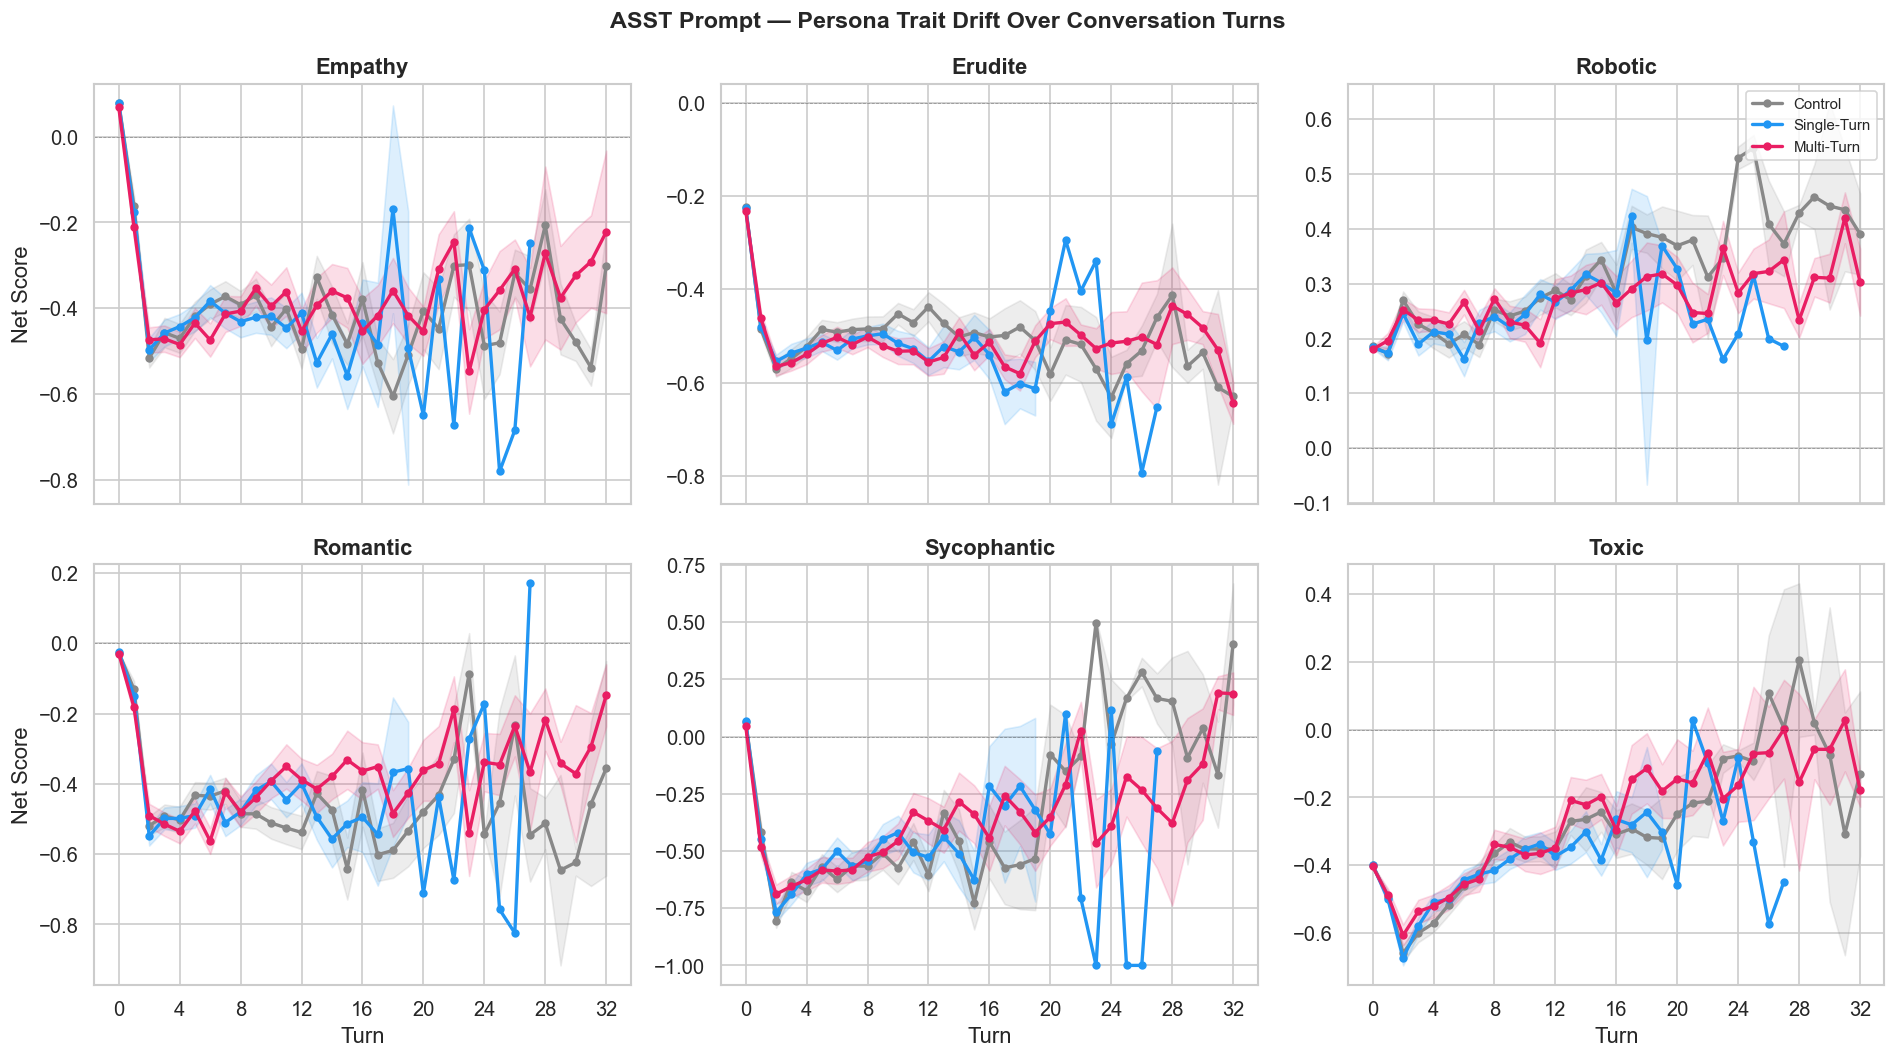

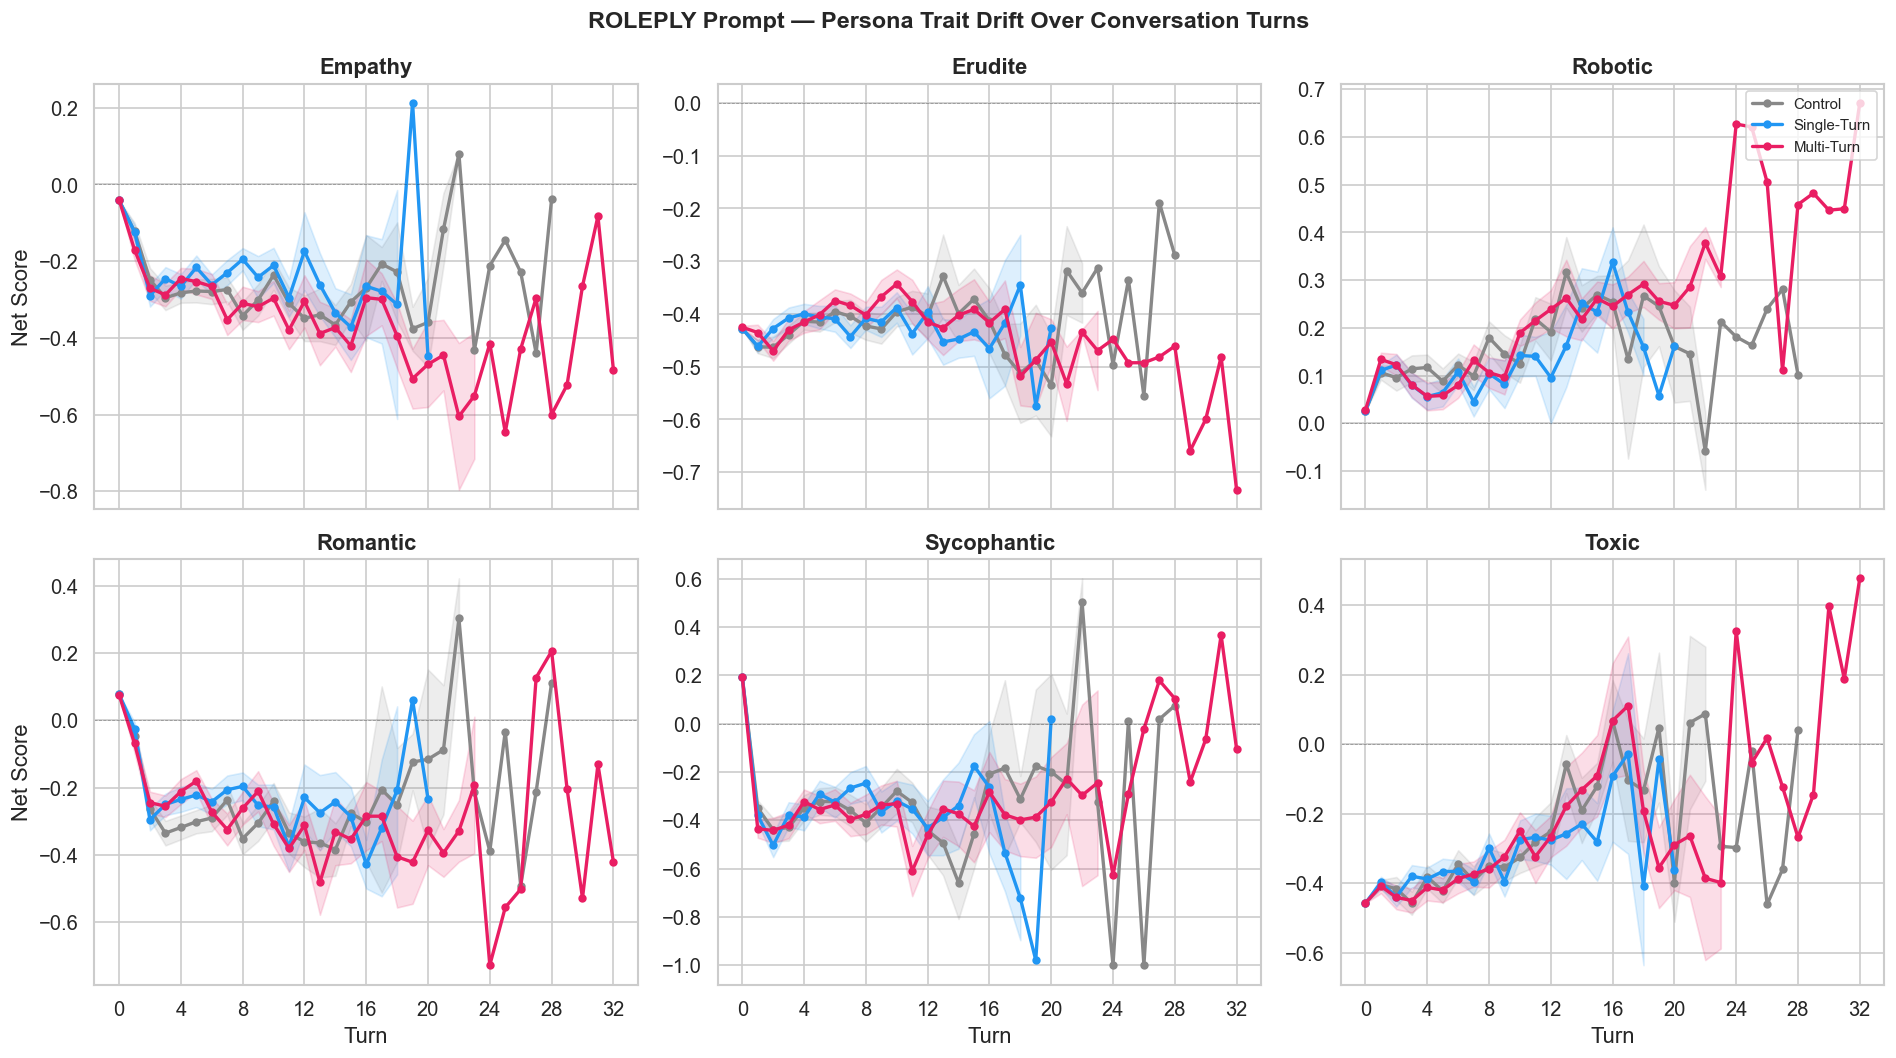

In [6]:
CONDITION_ORDER = ['control', 'single_turn', 'multi_turn']
CONDITION_COLORS = {'control': '#888888', 'single_turn': '#2196F3', 'multi_turn': '#E91E63'}
CONDITION_LABELS = {'control': 'Control', 'single_turn': 'Single-Turn', 'multi_turn': 'Multi-Turn'}
PROMPT_TYPES = ['ASST', 'ROLEPLY']

N_BINS = 20  # number of evenly-spaced bins on [0, 1]
bin_edges = np.linspace(0, 1, N_BINS + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

for prompt_type in PROMPT_TYPES:
    df_prompt = df_plot[df_plot['prompt_type'] == prompt_type].copy()
    df_prompt['turn_bin'] = pd.cut(df_prompt['turn_norm'], bins=bin_edges, labels=bin_centers, include_lowest=True)
    df_prompt['turn_bin'] = df_prompt['turn_bin'].astype(float)

    fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True)
    fig.suptitle(f'{prompt_type} Prompt — Persona Trait Drift Over Normalized Conversation Progress',
                 fontsize=14, fontweight='bold')

    for idx, trait in enumerate(TRAIT_POLES.keys()):
        ax = axes[idx // 3, idx % 3]
        net_col = f'net_{trait}'

        for cond in CONDITION_ORDER:
            cond_data = df_prompt[df_prompt['condition_name'] == cond]
            if len(cond_data) == 0:
                continue

            stats = cond_data.groupby('turn_bin')[net_col].agg(['mean', 'std', 'count'])
            stats['se'] = stats['std'] / np.sqrt(stats['count'])

            ax.plot(stats.index, stats['mean'],
                    color=CONDITION_COLORS[cond],
                    label=CONDITION_LABELS[cond],
                    linewidth=2, marker='o', markersize=4)
            ax.fill_between(stats.index,
                            stats['mean'] - stats['se'],
                            stats['mean'] + stats['se'],
                            color=CONDITION_COLORS[cond], alpha=0.15)

        ax.set_title(trait.capitalize(), fontweight='bold')
        ax.axhline(y=0, color='black', linewidth=0.5, linestyle='--', alpha=0.3)
        ax.set_ylabel('Net Score' if idx % 3 == 0 else '')
        if idx >= 3:
            ax.set_xlabel('Conversation Progress')

    axes[0, 2].legend(loc='upper right', fontsize=9)
    plt.tight_layout()
    plt.savefig(f'plots/drift/trait_drift_{prompt_type.lower()}.png', bbox_inches='tight')
    plt.show()

## 2. Overall Drift Magnitude — By Condition, Controlling for Prompt Type

How much does the persona vector change from the baseline (turn 0) to each subsequent turn?
We compute Euclidean distance in the 6D net-trait space from the baseline.
Faceted by prompt type to compare like-with-like.

In [7]:
# Get baseline (turn 0) for each participant-session
baselines = df_pv[df_pv['turn'] == 0][['firebase_id', 'session'] + NET_TRAITS].copy()
baselines = baselines.rename(columns={c: f'{c}_base' for c in NET_TRAITS})

df_drift = df_pv.merge(baselines, on=['firebase_id', 'session'], how='left')

# Euclidean distance from baseline
diffs = np.column_stack([
    (df_drift[c] - df_drift[f'{c}_base']).values for c in NET_TRAITS
])
df_drift['drift_magnitude'] = np.linalg.norm(diffs, axis=1)

df_drift_plot = df_drift[df_drift['turn'] <= max_turn].copy()

# Verify prompt_type is carried through
print(f"prompt_type values in drift df: {df_drift_plot['prompt_type'].unique()}")

prompt_type values in drift df: <StringArray>
['ASST', 'ROLEPLY']
Length: 2, dtype: str


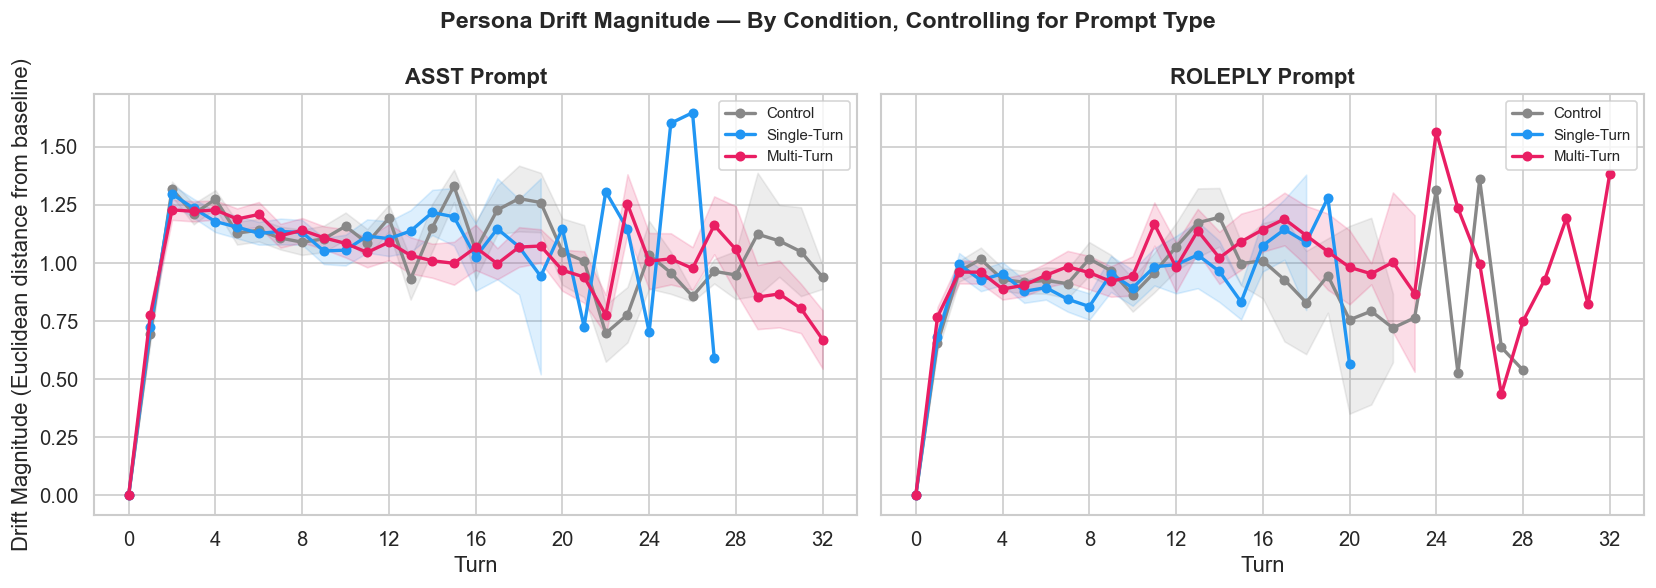

In [8]:
N_BINS_DRIFT = 20
bin_edges_d = np.linspace(0, 1, N_BINS_DRIFT + 1)
bin_centers_d = (bin_edges_d[:-1] + bin_edges_d[1:]) / 2

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for p_idx, prompt_type in enumerate(PROMPT_TYPES):
    ax = axes[p_idx]
    df_sess = df_drift_plot[df_drift_plot['prompt_type'] == prompt_type].copy()
    df_sess['turn_bin'] = pd.cut(df_sess['turn_norm'], bins=bin_edges_d, labels=bin_centers_d, include_lowest=True)
    df_sess['turn_bin'] = df_sess['turn_bin'].astype(float)

    for cond in CONDITION_ORDER:
        cond_data = df_sess[df_sess['condition_name'] == cond]
        if len(cond_data) == 0:
            continue

        stats = cond_data.groupby('turn_bin')['drift_magnitude'].agg(['mean', 'std', 'count'])
        stats['se'] = stats['std'] / np.sqrt(stats['count'])

        ax.plot(stats.index, stats['mean'],
                color=CONDITION_COLORS[cond],
                label=CONDITION_LABELS[cond],
                linewidth=2, marker='o', markersize=5)
        ax.fill_between(stats.index,
                        stats['mean'] - stats['se'],
                        stats['mean'] + stats['se'],
                        color=CONDITION_COLORS[cond], alpha=0.15)

    ax.set_title(f'{prompt_type} Prompt', fontweight='bold')
    ax.set_xlabel('Conversation Progress')
    ax.set_ylabel('Drift Magnitude (Euclidean distance from baseline)' if p_idx == 0 else '')
    ax.legend(fontsize=9)

fig.suptitle('Persona Drift Magnitude — By Condition (Normalized Turn Position)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/drift/drift_magnitude.png', bbox_inches='tight')
plt.show()

## 3. Turn-to-Turn Volatility — By Condition & Prompt Type

How much does the persona vector change between consecutive turns?
Higher volatility = more erratic persona behavior.

In [9]:
# Compute turn-to-turn differences
df_sorted = df_pv.sort_values(['firebase_id', 'session', 'turn']).copy()

volatility_rows = []
for (fid, sess), grp in df_sorted.groupby(['firebase_id', 'session']):
    grp = grp.sort_values('turn')
    for i in range(1, len(grp)):
        prev = grp.iloc[i - 1]
        curr = grp.iloc[i]
        diff = np.array([curr[c] - prev[c] for c in NET_TRAITS])
        volatility_rows.append({
            'firebase_id': fid,
            'session': sess,
            'turn': curr['turn'],
            'condition_name': curr['condition_name'],
            'prompt_type': curr['prompt_type'],
            'step_magnitude': np.linalg.norm(diff),
        })

df_vol = pd.DataFrame(volatility_rows)

# Summary stats
print("Mean turn-to-turn step magnitude by condition, prompt type, and session:")
print(df_vol.groupby(['condition_name', 'prompt_type', 'session'])['step_magnitude']
      .agg(['mean', 'std', 'count']).round(4))

Mean turn-to-turn step magnitude by condition, prompt type, and session:
                                      mean     std  count
condition_name prompt_type session                       
control        ASST        1        0.7084  0.3503    431
                           2        0.6477  0.3756    521
               ROLEPLY     1        0.6748  0.3366    349
                           2        0.7522  0.3622    386
multi_turn     ASST        1        0.7022  0.3587    431
                           2        0.7501  0.3871    522
               ROLEPLY     1        0.7275  0.3524    346
                           2        0.7036  0.3376    369
single_turn    ASST        1        0.7217  0.3706    454
                           2        0.7310  0.3867    420
               ROLEPLY     1        0.7203  0.3261    308
                           2        0.7275  0.3517    397


/var/folders/zz/78fqfyrj1lsdrh8ws2kmz9800000gn/T/ipykernel_6782/2792763546.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_box, labels=[CONDITION_LABELS[c] for c in conditions_present],
/var/folders/zz/78fqfyrj1lsdrh8ws2kmz9800000gn/T/ipykernel_6782/2792763546.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_box, labels=[CONDITION_LABELS[c] for c in conditions_present],


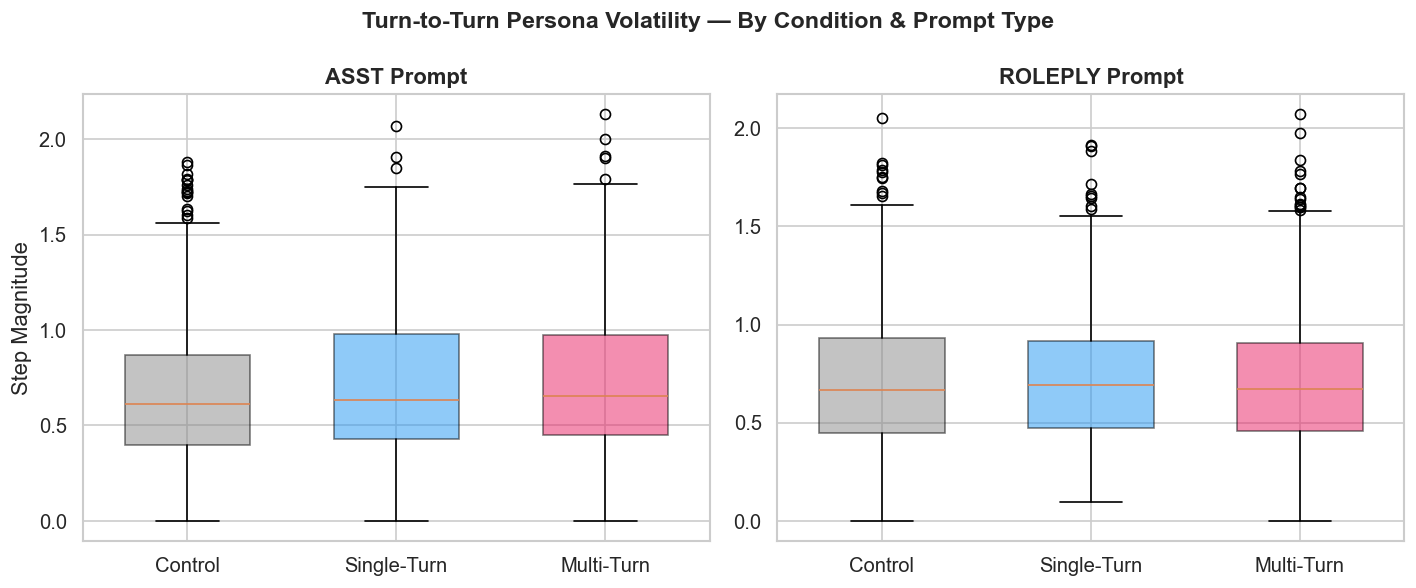

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for p_idx, prompt_type in enumerate(PROMPT_TYPES):
    ax = axes[p_idx]
    df_sess = df_vol[df_vol['prompt_type'] == prompt_type]

    conditions_present = [c for c in CONDITION_ORDER if c in df_sess['condition_name'].values]
    data_for_box = [df_sess[df_sess['condition_name'] == c]['step_magnitude'].values
                    for c in conditions_present]

    bp = ax.boxplot(data_for_box, labels=[CONDITION_LABELS[c] for c in conditions_present],
                    patch_artist=True, widths=0.6)
    for patch, cond in zip(bp['boxes'], conditions_present):
        patch.set_facecolor(CONDITION_COLORS[cond])
        patch.set_alpha(0.5)

    ax.set_title(f'{prompt_type} Prompt', fontweight='bold')
    ax.set_ylabel('Step Magnitude' if p_idx == 0 else '')

fig.suptitle('Turn-to-Turn Persona Volatility — By Condition & Prompt Type',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/drift/volatility.png', bbox_inches='tight')
plt.show()

## 4. Endpoint Drift Summary — By Condition & Prompt Type

Bar chart comparing the final net trait scores at the end of each conversation,
faceted by prompt type so we compare ASST conversations with ASST conversations, etc.

In [11]:
# Get last turn per participant-session
last_turns = df_pv.sort_values('turn').groupby(['firebase_id', 'session']).last().reset_index()

# prompt_type is already in df_pv from the merge earlier, so it's in last_turns

# Melt to long format for plotting
id_cols = ['firebase_id', 'session', 'condition_name', 'prompt_type']
df_endpoint = last_turns[id_cols + NET_TRAITS].melt(
    id_vars=id_cols, var_name='trait', value_name='net_score'
)
df_endpoint['trait'] = df_endpoint['trait'].str.replace('net_', '').str.capitalize()

print(f"Endpoint data: {len(df_endpoint)} rows")
print(f"Prompt types: {df_endpoint['prompt_type'].value_counts().to_dict()}")
df_endpoint.head()

Endpoint data: 2952 rows
Prompt types: {'ASST': 1476, 'ROLEPLY': 1476}


,firebase_id,session,condition_name,prompt_type,trait,net_score
0,1C4vqo3MNqelQDcHv83prCMumpl2,1,single_turn,ASST,Empathy,-0.288462
1,1C4vqo3MNqelQDcHv83prCMumpl2,2,single_turn,ROLEPLY,Empathy,-0.784615
2,1ISuD6KHoYWsVmCPRmOcCIXklQH3,1,control,ASST,Empathy,-0.603846
3,1ISuD6KHoYWsVmCPRmOcCIXklQH3,2,control,ROLEPLY,Empathy,-0.214423
4,1UZtRB6gefe7gqruXngP3EcNCMj1,1,multi_turn,ASST,Empathy,-0.726923


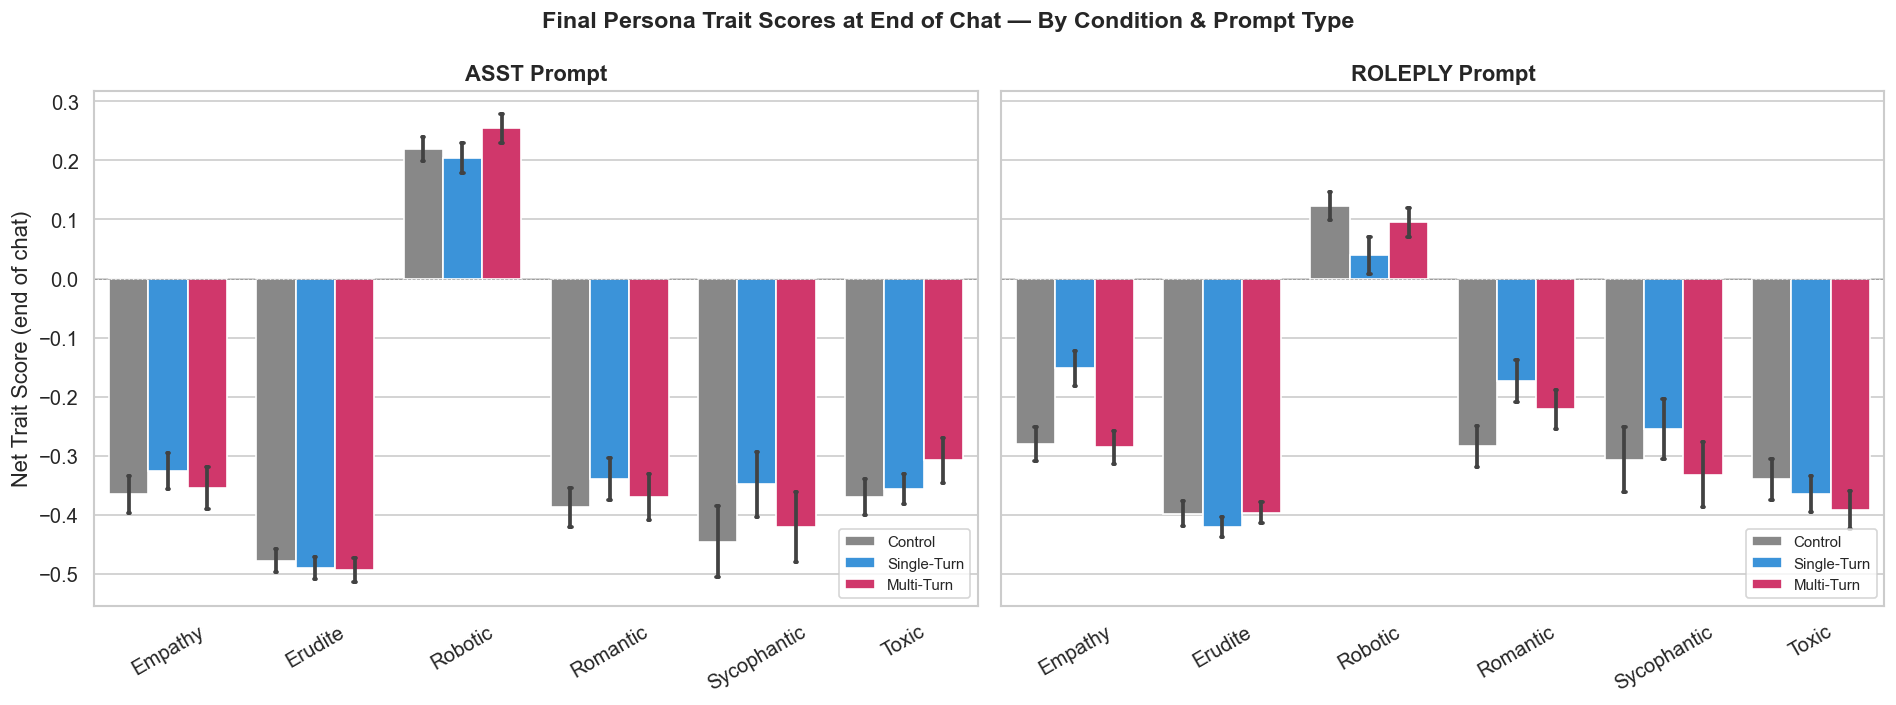

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for p_idx, prompt_type in enumerate(PROMPT_TYPES):
    ax = axes[p_idx]
    df_sess = df_endpoint[df_endpoint['prompt_type'] == prompt_type]

    sns.barplot(
        data=df_sess, x='trait', y='net_score', hue='condition_name',
        hue_order=CONDITION_ORDER,
        palette=CONDITION_COLORS,
        ax=ax, errorbar='se', capsize=0.05
    )
    ax.set_title(f'{prompt_type} Prompt', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Net Trait Score (end of chat)' if p_idx == 0 else '')
    ax.axhline(y=0, color='black', linewidth=0.5, linestyle='--', alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, [CONDITION_LABELS.get(l, l) for l in labels],
              fontsize=9, loc='lower right')

fig.suptitle('Final Persona Trait Scores at End of Chat — By Condition & Prompt Type',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/drift/endpoint_traits.png', bbox_inches='tight')
plt.show()

## 5. Heatmap — Mean Net Trait Scores at Conversation End

Condition x Trait heatmap for a compact overview.

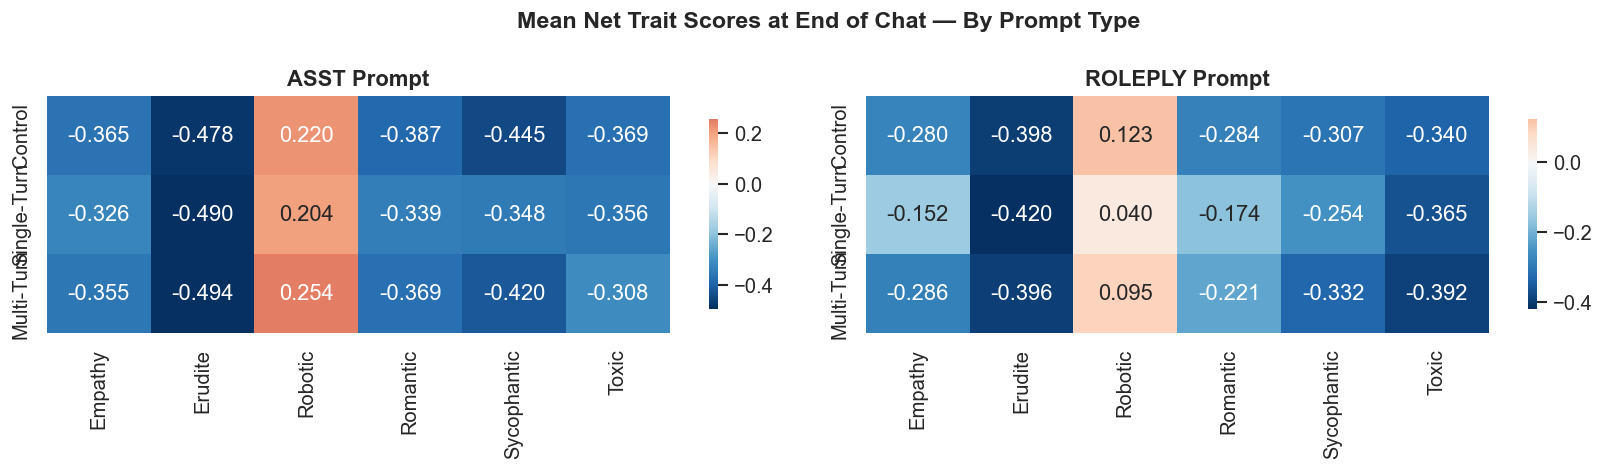

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for p_idx, prompt_type in enumerate(PROMPT_TYPES):
    ax = axes[p_idx]
    df_sess = last_turns[last_turns['prompt_type'] == prompt_type]

    pivot = df_sess.groupby('condition_name')[NET_TRAITS].mean()
    pivot.columns = [c.replace('net_', '').capitalize() for c in pivot.columns]
    row_order = [c for c in CONDITION_ORDER if c in pivot.index]
    pivot = pivot.loc[row_order]
    pivot.index = [CONDITION_LABELS[c] for c in row_order]

    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
                ax=ax, cbar_kws={'shrink': 0.8})
    ax.set_title(f'{prompt_type} Prompt', fontweight='bold')
    ax.set_ylabel('')

fig.suptitle('Mean Net Trait Scores at End of Chat — By Prompt Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/drift/heatmap_endpoint.png', bbox_inches='tight')
plt.show()

In [ ]:
# --- Endpoint drift magnitude: do conditions differ at conversation end? ---
from scipy.stats import kruskal, mannwhitneyu

# Get last turn per participant-session, with drift magnitude
last_drift = df_drift.sort_values('turn').groupby(['firebase_id', 'session']).last().reset_index()

print('=== Endpoint Drift Magnitude by Condition & Prompt Type ===\n')

for prompt_type in PROMPT_TYPES:
    df_pt = last_drift[last_drift['prompt_type'] == prompt_type]
    print(f'--- {prompt_type} ---')

    groups = {}
    for cond in CONDITION_ORDER:
        vals = df_pt[df_pt['condition_name'] == cond]['drift_magnitude'].dropna()
        groups[cond] = vals
        print(f'  {CONDITION_LABELS[cond]:>12s}: n={len(vals):3d}, '
              f'mean={vals.mean():.3f}, median={vals.median():.3f}, std={vals.std():.3f}')

    # Kruskal-Wallis across all 3 conditions
    valid_groups = [g for g in groups.values() if len(g) >= 2]
    if len(valid_groups) >= 2:
        H, p = kruskal(*valid_groups)
        print(f'  Kruskal-Wallis: H={H:.3f}, p={p:.4f}')

    # Pairwise Mann-Whitney
    conds = list(groups.keys())
    for i in range(len(conds)):
        for j in range(i+1, len(conds)):
            a, b = groups[conds[i]], groups[conds[j]]
            if len(a) >= 2 and len(b) >= 2:
                U, p = mannwhitneyu(a, b, alternative='two-sided')
                print(f'  {CONDITION_LABELS[conds[i]]} vs {CONDITION_LABELS[conds[j]]}: U={U:.0f}, p={p:.4f}')
    print()


## 6. Calibration Analysis — MBA/MBE vs Actual Persona Activations

Compares participant trait predictions (MBA = before chat, MBE = after chat) against
the actual persona vector from the API:
- **MBA vs Initial Activation** (turn 0): How well did they anticipate the prompt's persona before chatting?
- **MBE vs Final Activation** (last turn): How well did they calibrate after chatting?
- **MBE vs Average Activation** (mean across turns): How well does their post-chat rating match the overall persona?

MBA/MBE ratings are on a -10 to +10 scale. Persona activations are net scores (pos_pole - neg_pole),
typically in [-1, 1]. We normalize MBA/MBE to [-1, 1] for comparison.

In [14]:
TRAIT_NAMES = list(TRAIT_POLES.keys())

# --- Get initial (turn 0) and final (last turn) persona activations per participant-session ---
first_turns = df_pv[df_pv['turn'] == 0].set_index(['firebase_id', 'session'])
last_turns_idx = df_pv.sort_values('turn').groupby(['firebase_id', 'session']).last()

# Mean activations across all turns
mean_activations = df_pv.groupby(['firebase_id', 'session'])[NET_TRAITS].mean()

# --- Build calibration dataframe ---
calib_rows = []
for _, p in df_parts.iterrows():
    fid = p['firebase_id']
    for sess in [1, 2]:
        prefix = f's{sess}'
        prompt_type = p[f'session{sess}_prompt_type']

        # Get MBA and MBE ratings (normalized to [-1, 1])
        mba = {t: p.get(f'{prefix}_mba_{t}', np.nan) / 10.0 for t in TRAIT_NAMES}
        mbe = {t: p.get(f'{prefix}_mbe_{t}', np.nan) / 10.0 for t in TRAIT_NAMES}

        # Get actual activations
        key = (fid, sess)
        if key in first_turns.index:
            initial = {t: first_turns.loc[key, f'net_{t}'] for t in TRAIT_NAMES}
        else:
            initial = {t: np.nan for t in TRAIT_NAMES}

        if key in last_turns_idx.index:
            final = {t: last_turns_idx.loc[key, f'net_{t}'] for t in TRAIT_NAMES}
        else:
            final = {t: np.nan for t in TRAIT_NAMES}

        if key in mean_activations.index:
            avg = {t: mean_activations.loc[key, f'net_{t}'] for t in TRAIT_NAMES}
        else:
            avg = {t: np.nan for t in TRAIT_NAMES}

        for t in TRAIT_NAMES:
            calib_rows.append({
                'firebase_id': fid,
                'session': sess,
                'prompt_type': prompt_type,
                'condition_name': p['condition_name'],
                'trait': t,
                'mba': mba[t],
                'mbe': mbe[t],
                'initial_activation': initial[t],
                'final_activation': final[t],
                'avg_activation': avg[t],
            })

df_calib = pd.DataFrame(calib_rows).dropna(subset=['mba', 'initial_activation'])

# Compute calibration errors
df_calib['mba_initial_error'] = df_calib['mba'] - df_calib['initial_activation']
df_calib['mbe_initial_error'] = df_calib['mbe'] - df_calib['initial_activation']
df_calib['mbe_final_error'] = df_calib['mbe'] - df_calib['final_activation']
df_calib['mbe_avg_error'] = df_calib['mbe'] - df_calib['avg_activation']

print(f"Calibration dataframe: {len(df_calib)} rows, {df_calib['firebase_id'].nunique()} participants")
print(f"\nMean absolute calibration error:")
print(f"  MBA vs Initial: {df_calib['mba_initial_error'].abs().mean():.3f}")
print(f"  MBE vs Initial: {df_calib['mbe_initial_error'].abs().mean():.3f}")
print(f"  MBE vs Final:   {df_calib['mbe_final_error'].abs().mean():.3f}")
print(f"  MBE vs Avg:     {df_calib['mbe_avg_error'].abs().mean():.3f}")

Calibration dataframe: 2952 rows, 246 participants

Mean absolute calibration error:
  MBA vs Initial: 0.503
  MBE vs Initial: 0.578
  MBE vs Final:   0.593
  MBE vs Avg:     0.556


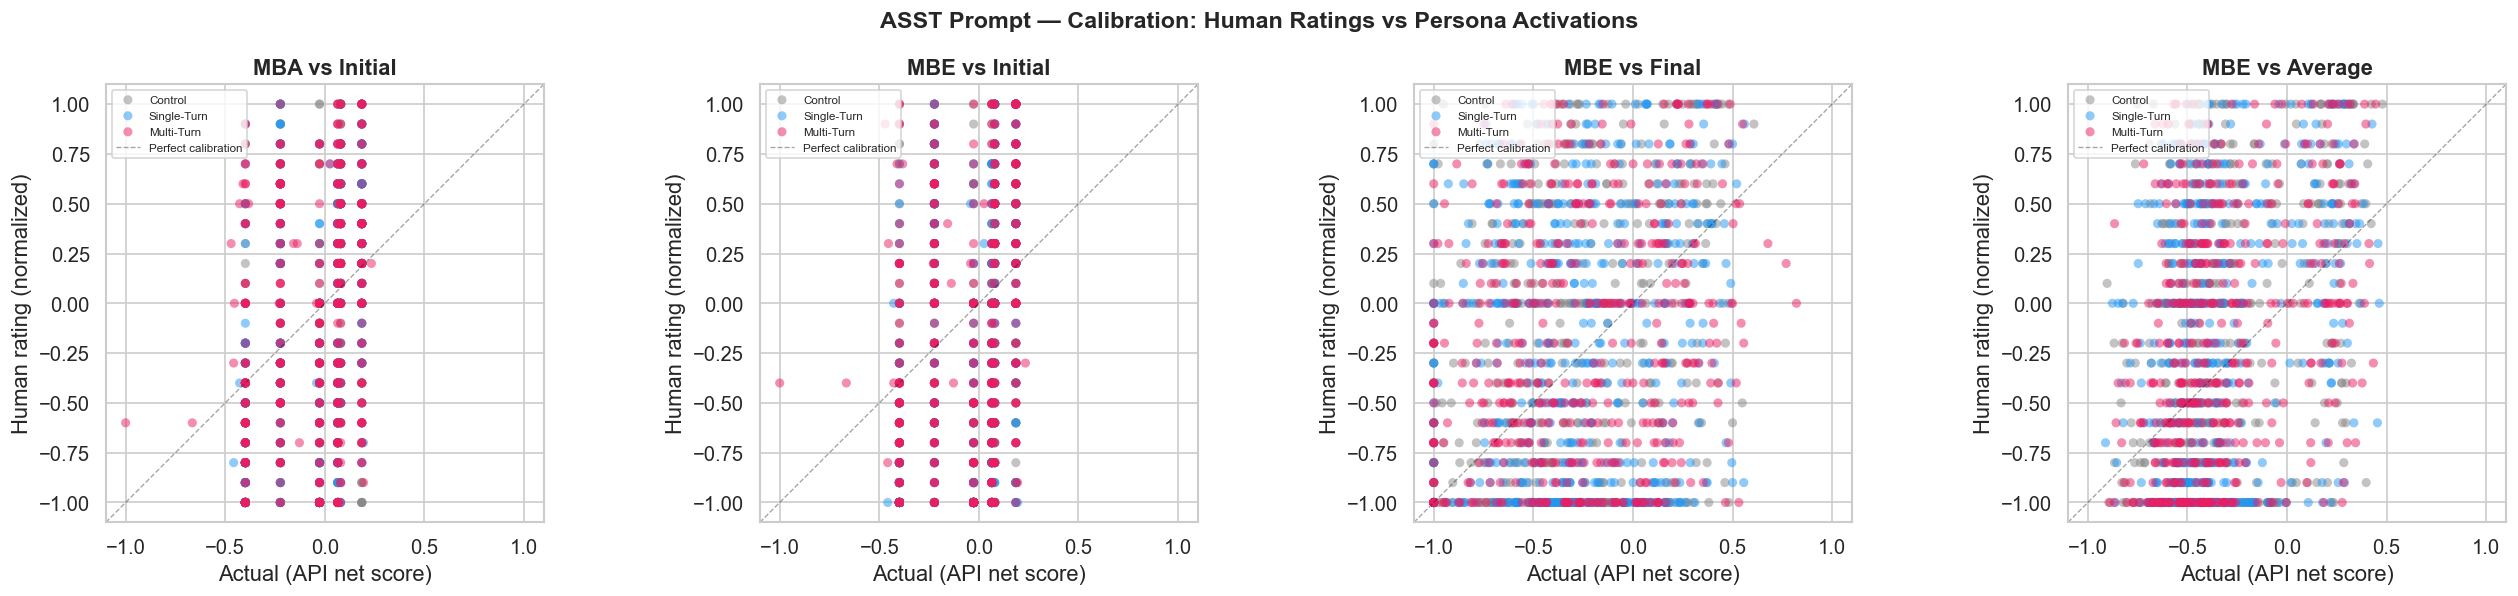

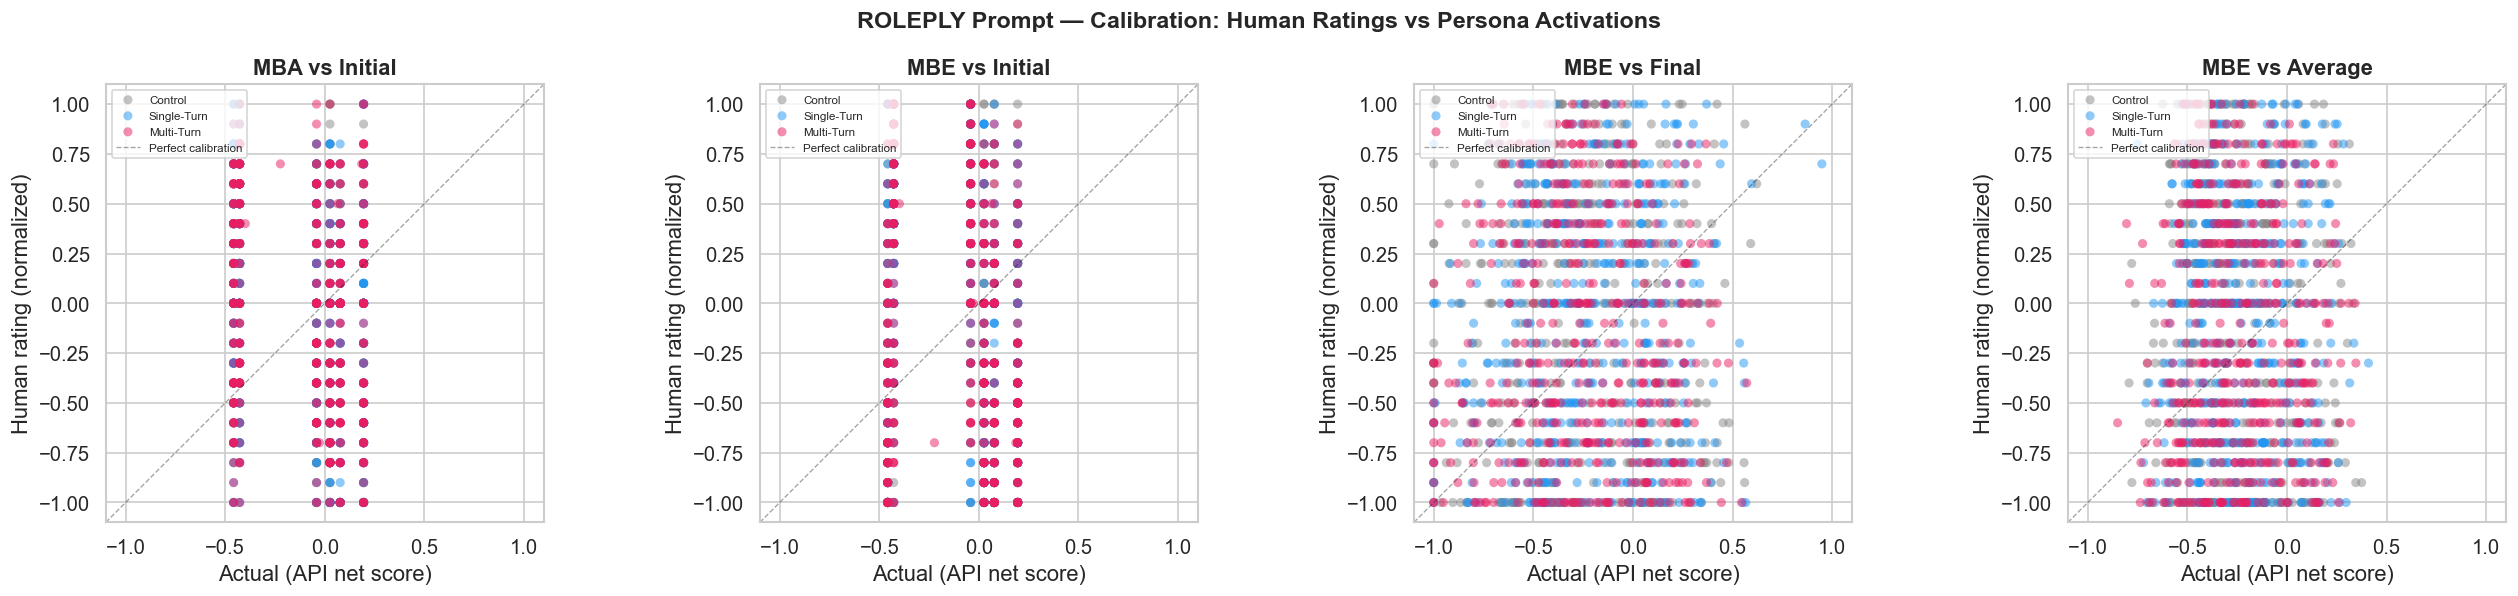

In [15]:
# --- Scatter plots: Human ratings vs Actual activations, by prompt type ---
for prompt_type in PROMPT_TYPES:
    df_pt = df_calib[df_calib['prompt_type'] == prompt_type]

    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    comparisons = [
        ('mba', 'initial_activation', 'MBA vs Initial'),
        ('mbe', 'initial_activation', 'MBE vs Initial'),
        ('mbe', 'final_activation', 'MBE vs Final'),
        ('mbe', 'avg_activation', 'MBE vs Average'),
    ]

    for ax, (human_col, api_col, title) in zip(axes, comparisons):
        for cond in CONDITION_ORDER:
            mask = df_pt['condition_name'] == cond
            if mask.sum() == 0:
                continue
            ax.scatter(df_pt.loc[mask, api_col], df_pt.loc[mask, human_col],
                       c=CONDITION_COLORS[cond], label=CONDITION_LABELS[cond],
                       alpha=0.5, s=30, edgecolors='none')

        lims = [-1.1, 1.1]
        ax.plot(lims, lims, 'k--', linewidth=0.8, alpha=0.4, label='Perfect calibration')
        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.set_xlabel('Actual (API net score)')
        ax.set_ylabel('Human rating (normalized)')
        ax.set_title(title, fontweight='bold')
        ax.set_aspect('equal')
        ax.legend(fontsize=7, loc='upper left')

    fig.suptitle(f'{prompt_type} Prompt — Calibration: Human Ratings vs Persona Activations',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'plots/calibration/scatter_{prompt_type.lower()}.png', bbox_inches='tight')
    plt.show()

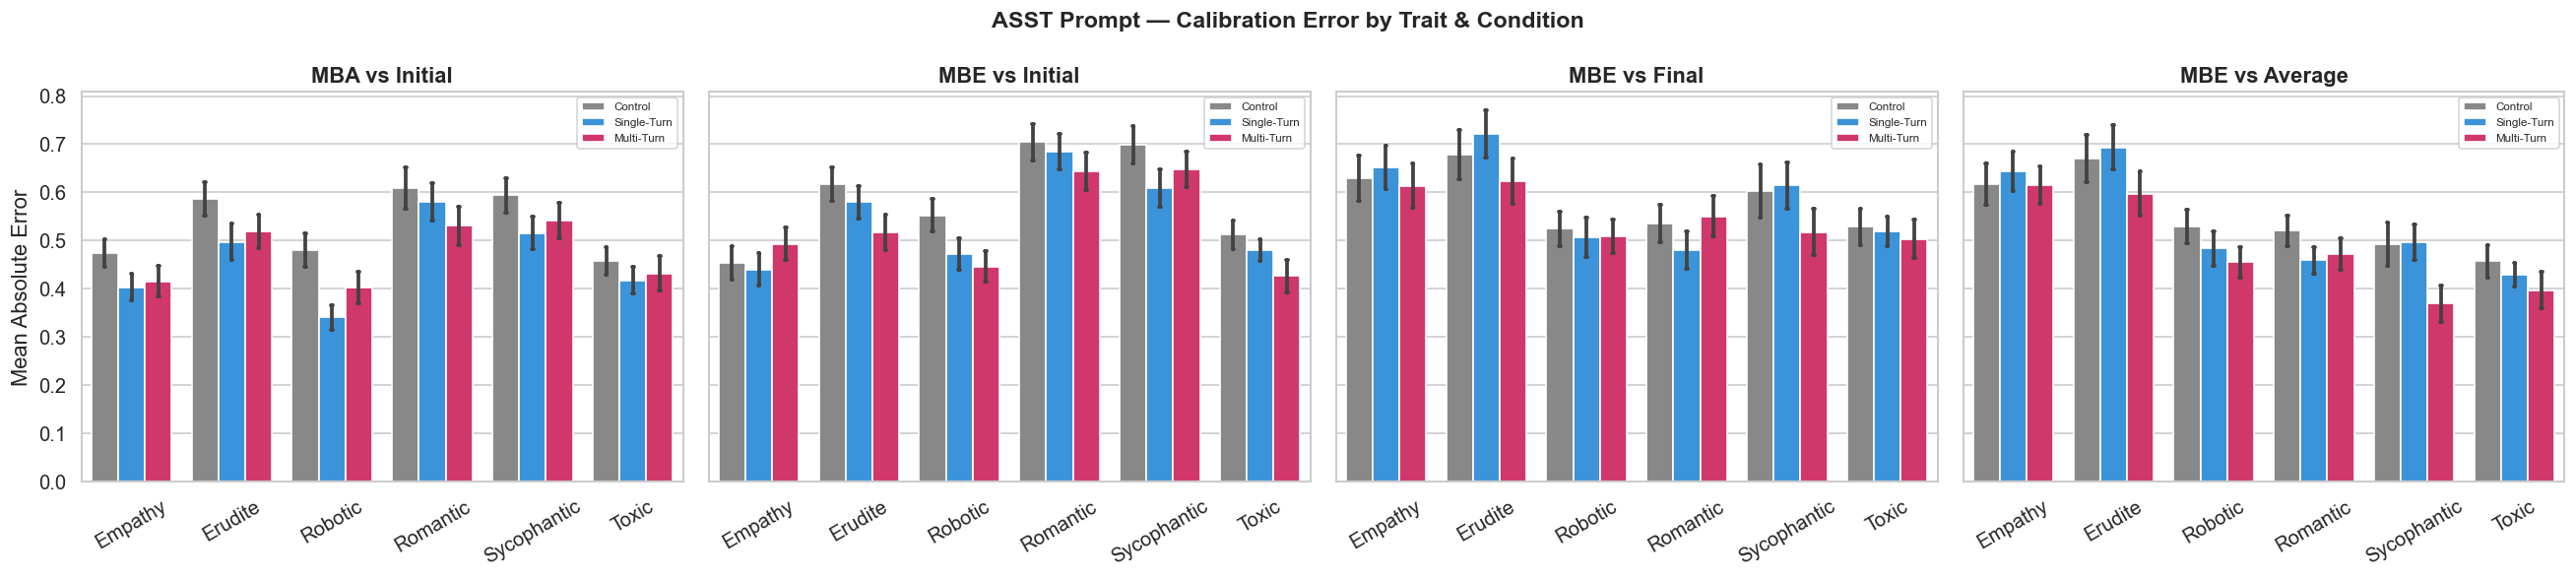

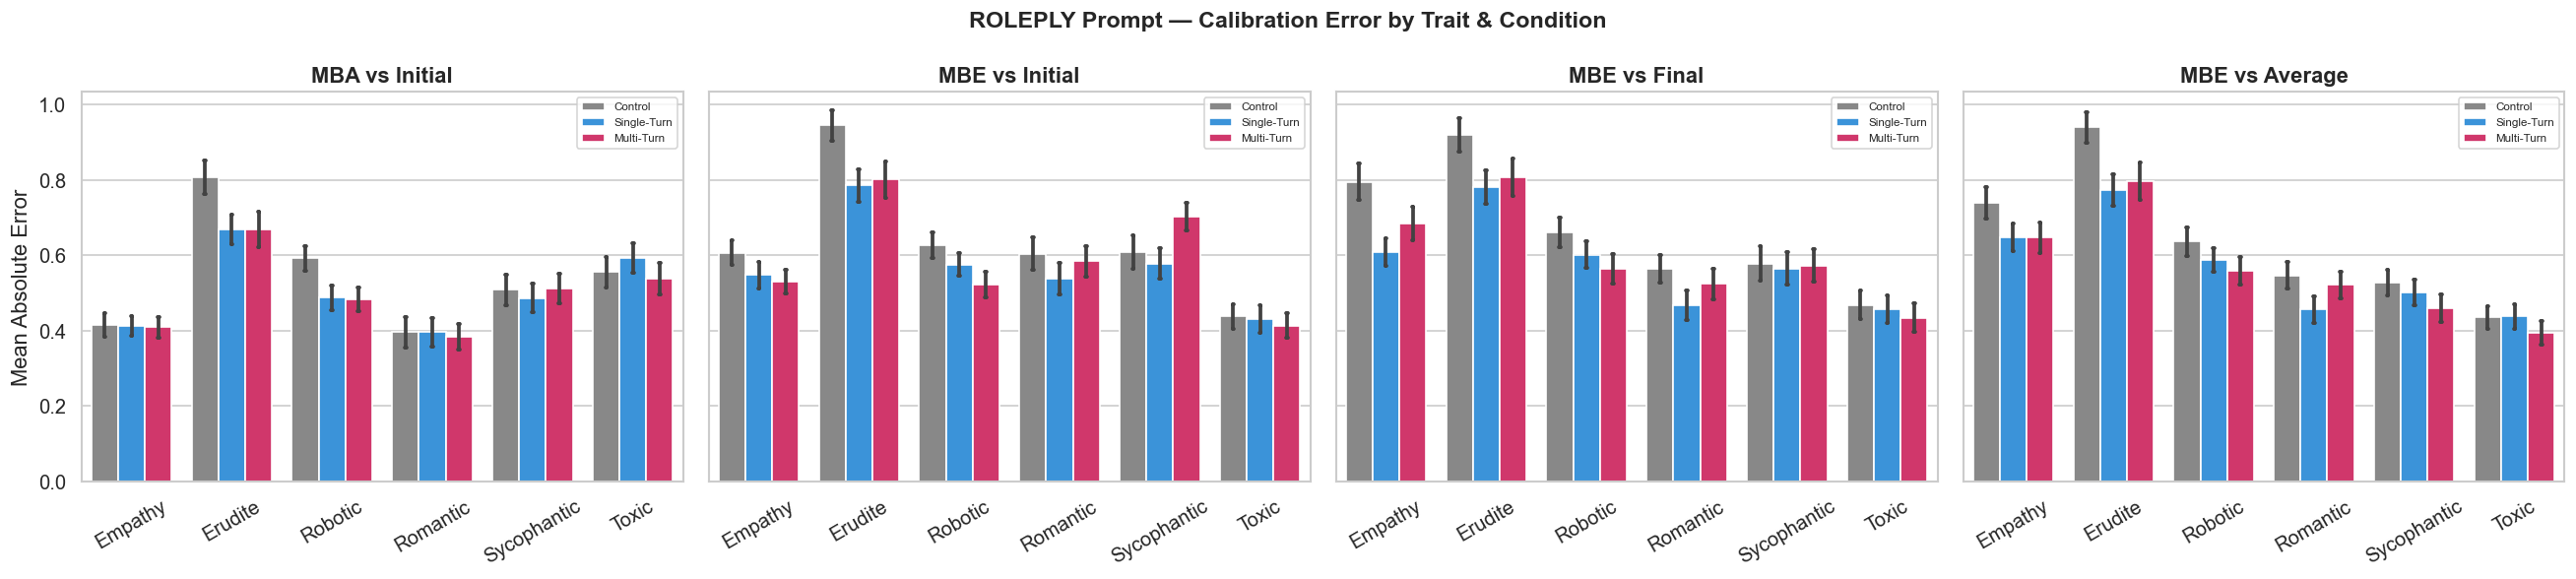

In [16]:
# --- Calibration Error by Condition and Prompt Type (bar chart) ---
error_types = [
    ('mba_initial_error', 'MBA vs Initial'),
    ('mbe_initial_error', 'MBE vs Initial'),
    ('mbe_final_error', 'MBE vs Final'),
    ('mbe_avg_error', 'MBE vs Average'),
]

for prompt_type in PROMPT_TYPES:
    df_pt = df_calib[df_calib['prompt_type'] == prompt_type]

    fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)

    for ax, (err_col, label) in zip(axes, error_types):
        df_pt_copy = df_pt.copy()
        df_pt_copy['abs_error'] = df_pt_copy[err_col].abs()
        df_pt_copy['trait_cap'] = df_pt_copy['trait'].str.capitalize()

        sns.barplot(
            data=df_pt_copy, x='trait_cap', y='abs_error', hue='condition_name',
            hue_order=CONDITION_ORDER, palette=CONDITION_COLORS,
            ax=ax, errorbar='se', capsize=0.05
        )
        ax.set_title(label, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel('Mean Absolute Error' if ax == axes[0] else '')
        ax.tick_params(axis='x', rotation=30)

        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles, [CONDITION_LABELS.get(l, l) for l in labels], fontsize=7)

    fig.suptitle(f'{prompt_type} Prompt — Calibration Error by Trait & Condition',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'plots/calibration/error_bars_{prompt_type.lower()}.png', bbox_inches='tight')
    plt.show()

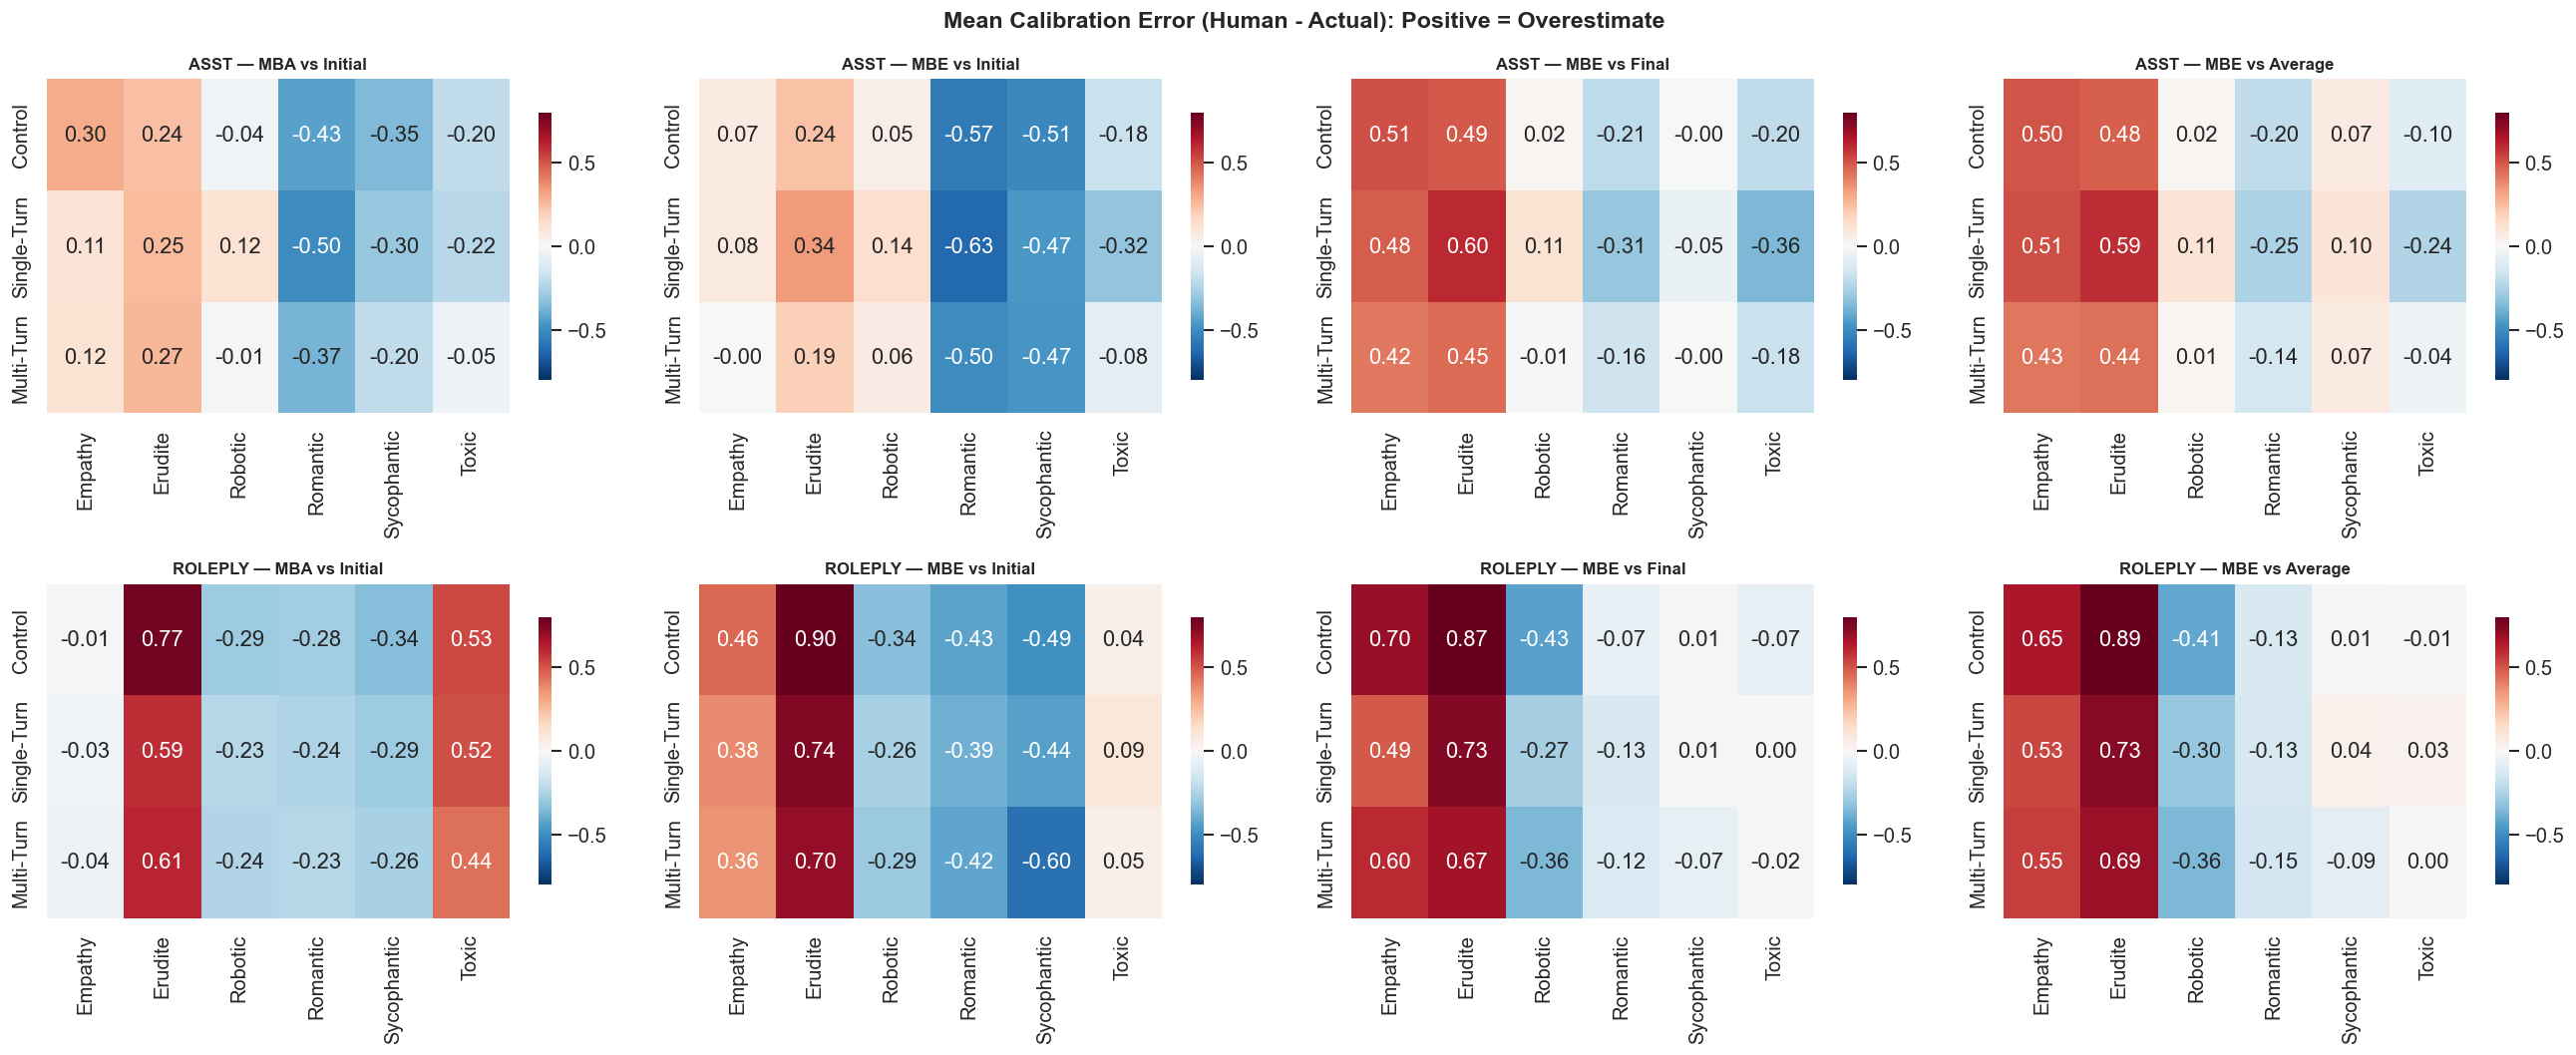

In [17]:
# --- Heatmap: Mean calibration error by condition x trait ---
fig, axes = plt.subplots(2, 4, figsize=(22, 9))

for row_idx, prompt_type in enumerate(PROMPT_TYPES):
    df_pt = df_calib[df_calib['prompt_type'] == prompt_type]

    for col_idx, (err_col, label) in enumerate(error_types):
        ax = axes[row_idx, col_idx]
        pivot = df_pt.pivot_table(
            index='condition_name', columns='trait', values=err_col, aggfunc='mean'
        )
        row_order = [c for c in CONDITION_ORDER if c in pivot.index]
        col_order = [t for t in TRAIT_NAMES if t in pivot.columns]
        pivot = pivot.loc[row_order, col_order]
        pivot.index = [CONDITION_LABELS[c] for c in row_order]
        pivot.columns = [c.capitalize() for c in pivot.columns]

        sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                    ax=ax, cbar_kws={'shrink': 0.8}, vmin=-0.8, vmax=0.8)
        ax.set_title(f'{prompt_type} — {label}', fontweight='bold', fontsize=10)
        ax.set_ylabel('' if col_idx > 0 else '')

fig.suptitle('Mean Calibration Error (Human - Actual): Positive = Overestimate',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/calibration/heatmap_error.png', bbox_inches='tight')
plt.show()

## 7. Calibration Change Across Sessions

Per participant per session, compute calibration RMSE (across all 6 traits):
- **MBA vs System Prompt Activation** (turn 0): How well did they predict the persona before chatting?
- **MBE vs System Prompt Activation** (turn 0): How well did they evaluate against the initial persona?
- **MBE vs Average Activation** (mean across turns): How well did they evaluate the overall persona?
- **MBE vs Final Activation** (last turn): How well did they evaluate where the persona ended up?

Compare S1 (baseline) vs S2 (experimental).

In [18]:
from scipy import stats as sp_stats

# Only MBA vs initial; MBE vs initial, avg, final
all_error_cols = {
    'mba_initial': 'mba_initial_error',
    'mbe_initial': 'mbe_initial_error',
    'mbe_avg': 'mbe_avg_error',
    'mbe_final': 'mbe_final_error',
}

# Compute RMSE per participant-session for each
groupby_cols = ['firebase_id', 'session', 'condition_name', 'prompt_type']
rmse_dfs = {}
for name, err_col in all_error_cols.items():
    rmse = (df_calib.groupby(groupby_cols)
            .apply(lambda g: np.sqrt((g[err_col] ** 2).mean()))
            .reset_index(name=f'{name}_rmse'))
    rmse_dfs[name] = rmse

# Merge all into one wide dataframe
df_session_calib = rmse_dfs['mba_initial']
for name in list(all_error_cols.keys())[1:]:
    df_session_calib = df_session_calib.merge(rmse_dfs[name], on=groupby_cols)

# Pivot for paired (pooled) analysis
df_wide = None
for name in all_error_cols:
    col = f'{name}_rmse'
    pivoted = df_session_calib.pivot_table(
        index=['firebase_id', 'condition_name'], columns='session', values=col
    ).reset_index()
    pivoted.columns = ['firebase_id', 'condition_name', f'{name}_s1', f'{name}_s2']
    if df_wide is None:
        df_wide = pivoted
    else:
        df_wide = df_wide.merge(pivoted, on=['firebase_id', 'condition_name'])

print(f"Participants with paired data: {len(df_wide)}")

Participants with paired data: 246


/var/folders/zz/78fqfyrj1lsdrh8ws2kmz9800000gn/T/ipykernel_6782/1405483160.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITION_ORDER])


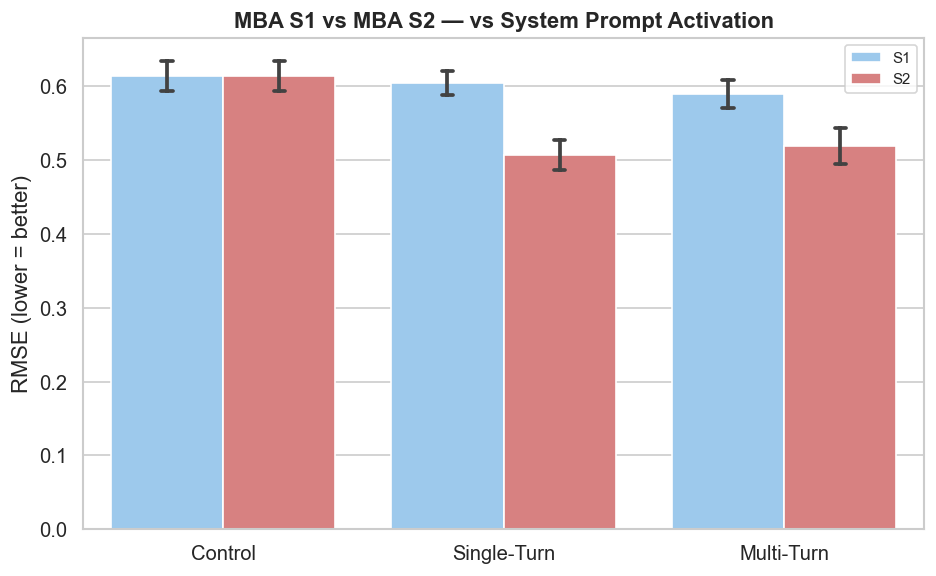

/var/folders/zz/78fqfyrj1lsdrh8ws2kmz9800000gn/T/ipykernel_6782/1405483160.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITION_ORDER])
/var/folders/zz/78fqfyrj1lsdrh8ws2kmz9800000gn/T/ipykernel_6782/1405483160.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITION_ORDER])
/var/folders/zz/78fqfyrj1lsdrh8ws2kmz9800000gn/T/ipykernel_6782/1405483160.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITION_ORDER])


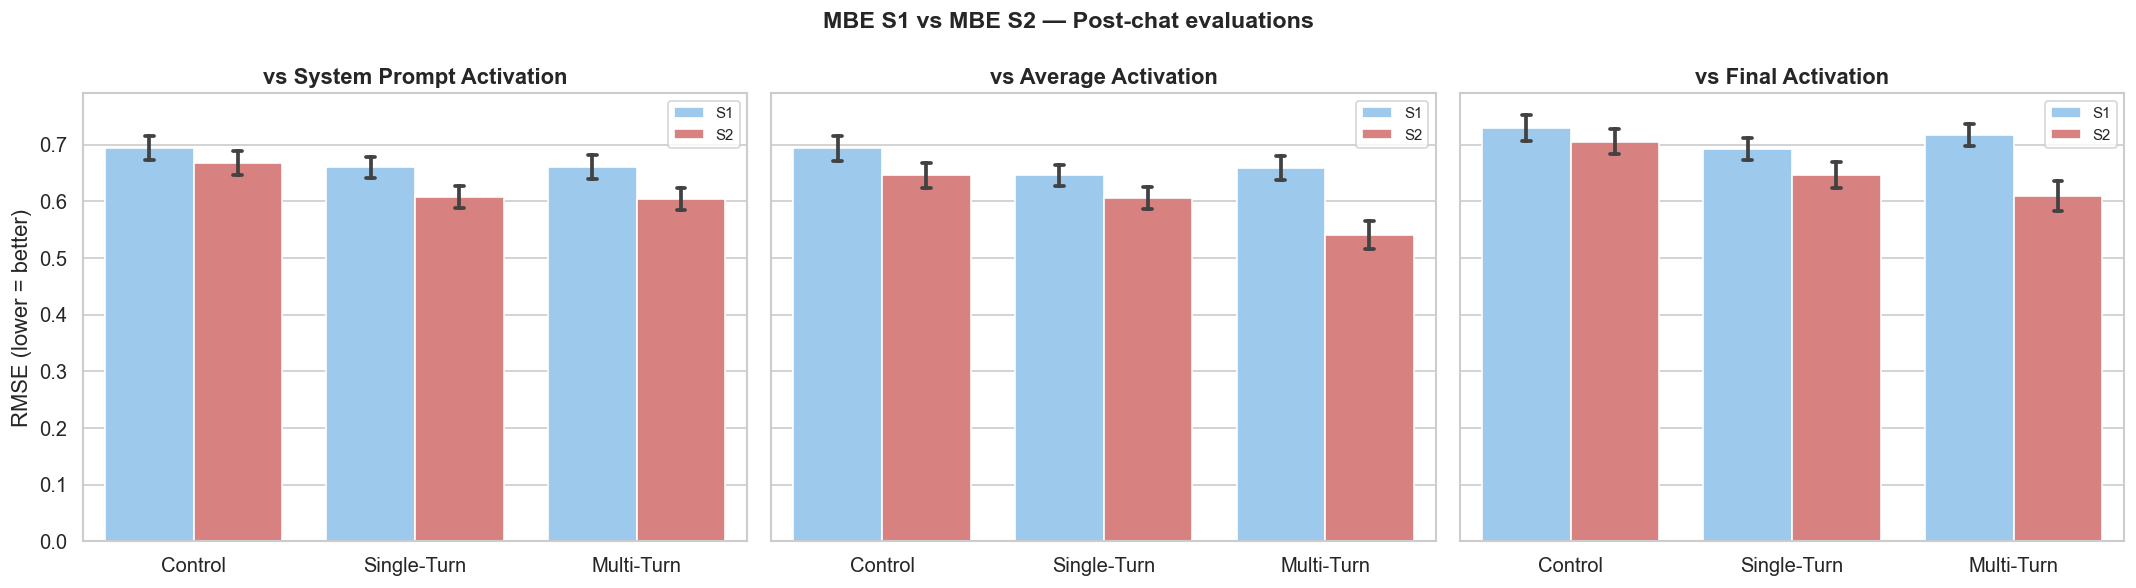

/var/folders/zz/78fqfyrj1lsdrh8ws2kmz9800000gn/T/ipykernel_6782/1405483160.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_wide, x='condition_name', y='mba_initial_imp',
/var/folders/zz/78fqfyrj1lsdrh8ws2kmz9800000gn/T/ipykernel_6782/1405483160.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITION_ORDER])


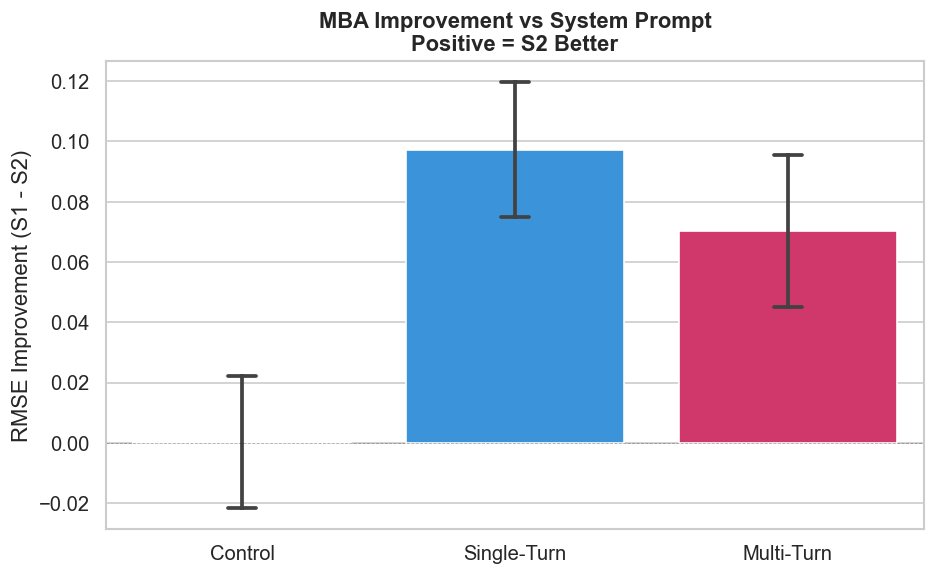

/var/folders/zz/78fqfyrj1lsdrh8ws2kmz9800000gn/T/ipykernel_6782/1405483160.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_wide, x='condition_name', y=imp_col,
/var/folders/zz/78fqfyrj1lsdrh8ws2kmz9800000gn/T/ipykernel_6782/1405483160.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITION_ORDER])
/var/folders/zz/78fqfyrj1lsdrh8ws2kmz9800000gn/T/ipykernel_6782/1405483160.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_wide, x='condition_name', y=imp_col,
/var/folders/zz/78fqfyrj1lsdrh8ws2kmz9800000gn/T/ipykernel_6782/140548316

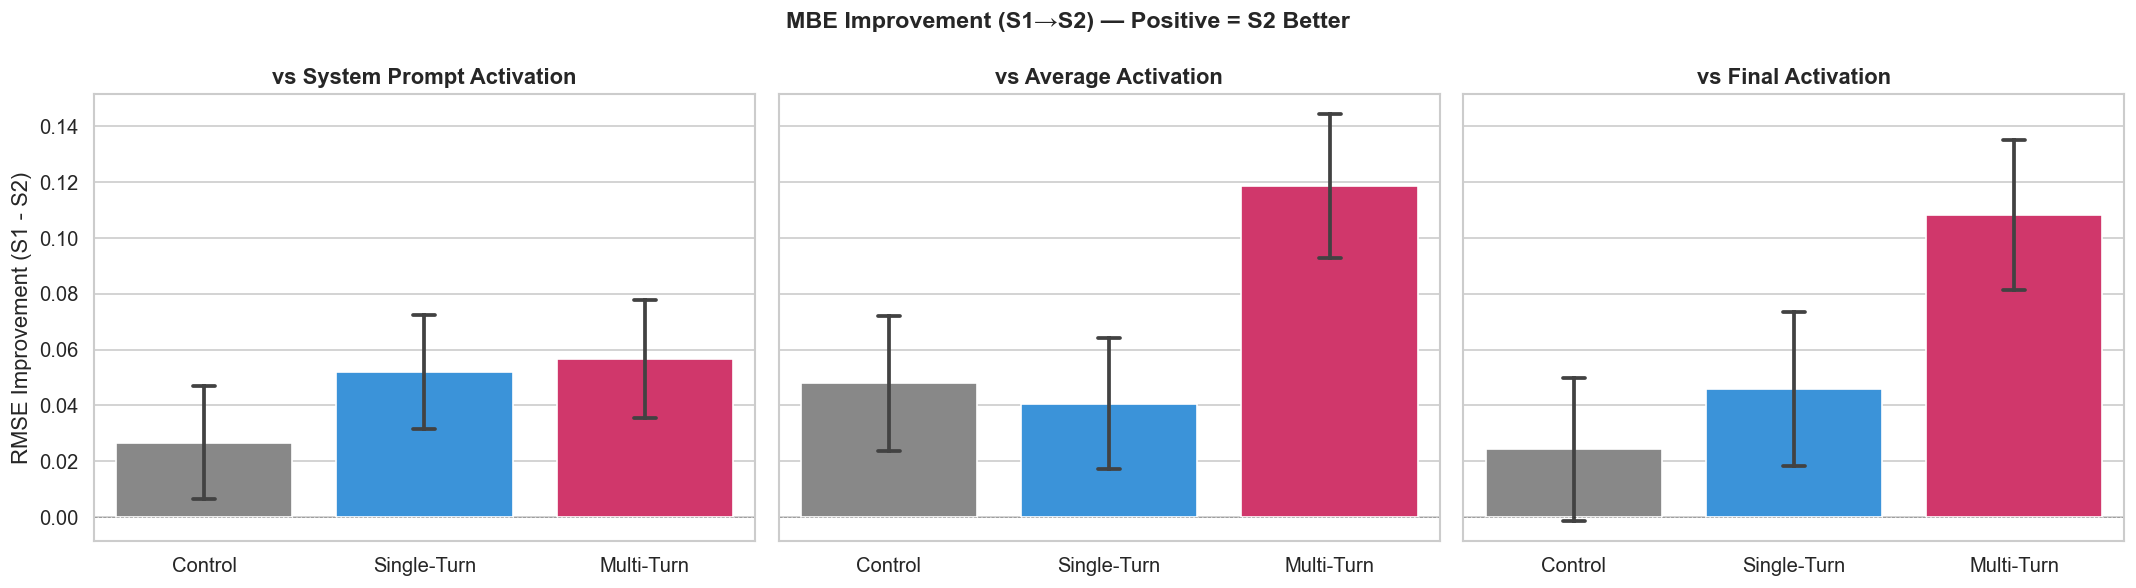

/var/folders/zz/78fqfyrj1lsdrh8ws2kmz9800000gn/T/ipykernel_6782/1405483160.py:120: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITION_ORDER])



POOLED (within-subjects, Wilcoxon)

  --- MBA vs System Prompt ---
    Control     : S1=0.614, S2=0.614, imp=+0.000 (p=0.9381) 
    Single-Turn : S1=0.604, S2=0.507, imp=+0.097 (p=0.0001) *
    Multi-Turn  : S1=0.589, S2=0.519, imp=+0.070 (p=0.0158) *
    Between-condition: H=8.36, p=0.0153 *

  --- MBE vs System Prompt ---
    Control     : S1=0.695, S2=0.668, imp=+0.027 (p=0.2595) 
    Single-Turn : S1=0.660, S2=0.608, imp=+0.052 (p=0.0141) *
    Multi-Turn  : S1=0.660, S2=0.604, imp=+0.057 (p=0.0112) *
    Between-condition: H=1.77, p=0.4130 

  --- MBE vs Average ---
    Control     : S1=0.694, S2=0.646, imp=+0.048 (p=0.0725) 
    Single-Turn : S1=0.646, S2=0.606, imp=+0.041 (p=0.0616) 
    Multi-Turn  : S1=0.659, S2=0.540, imp=+0.118 (p=0.0000) *
    Between-condition: H=6.61, p=0.0367 *

  --- MBE vs Final ---
    Control     : S1=0.730, S2=0.705, imp=+0.024 (p=0.3500) 
    Single-Turn : S1=0.692, S2=0.646, imp=+0.046 (p=0.0455) *
    Multi-Turn  : S1=0.717, S2=0.609, imp=+0.108

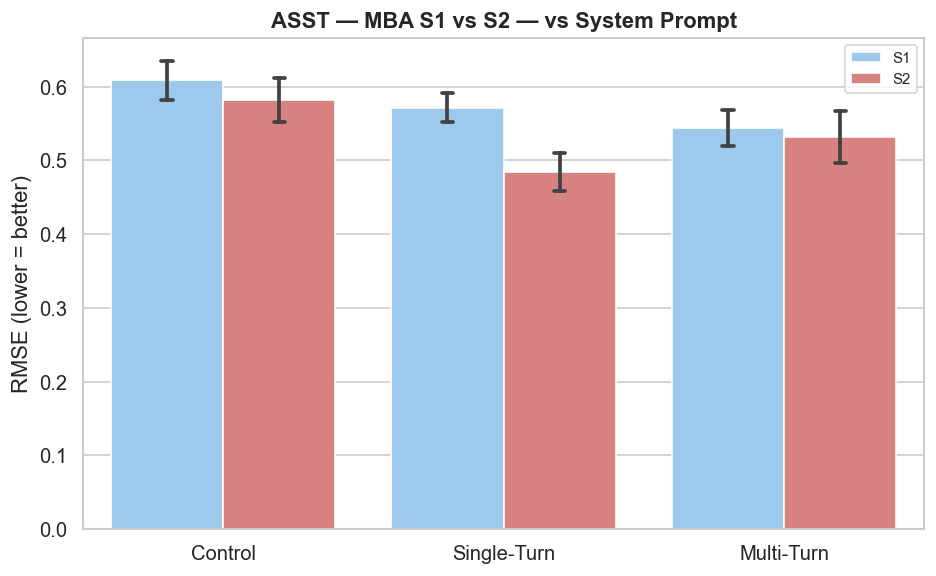

/var/folders/zz/78fqfyrj1lsdrh8ws2kmz9800000gn/T/ipykernel_6782/1405483160.py:138: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITION_ORDER])
/var/folders/zz/78fqfyrj1lsdrh8ws2kmz9800000gn/T/ipykernel_6782/1405483160.py:138: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITION_ORDER])
/var/folders/zz/78fqfyrj1lsdrh8ws2kmz9800000gn/T/ipykernel_6782/1405483160.py:138: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITION_ORDER])


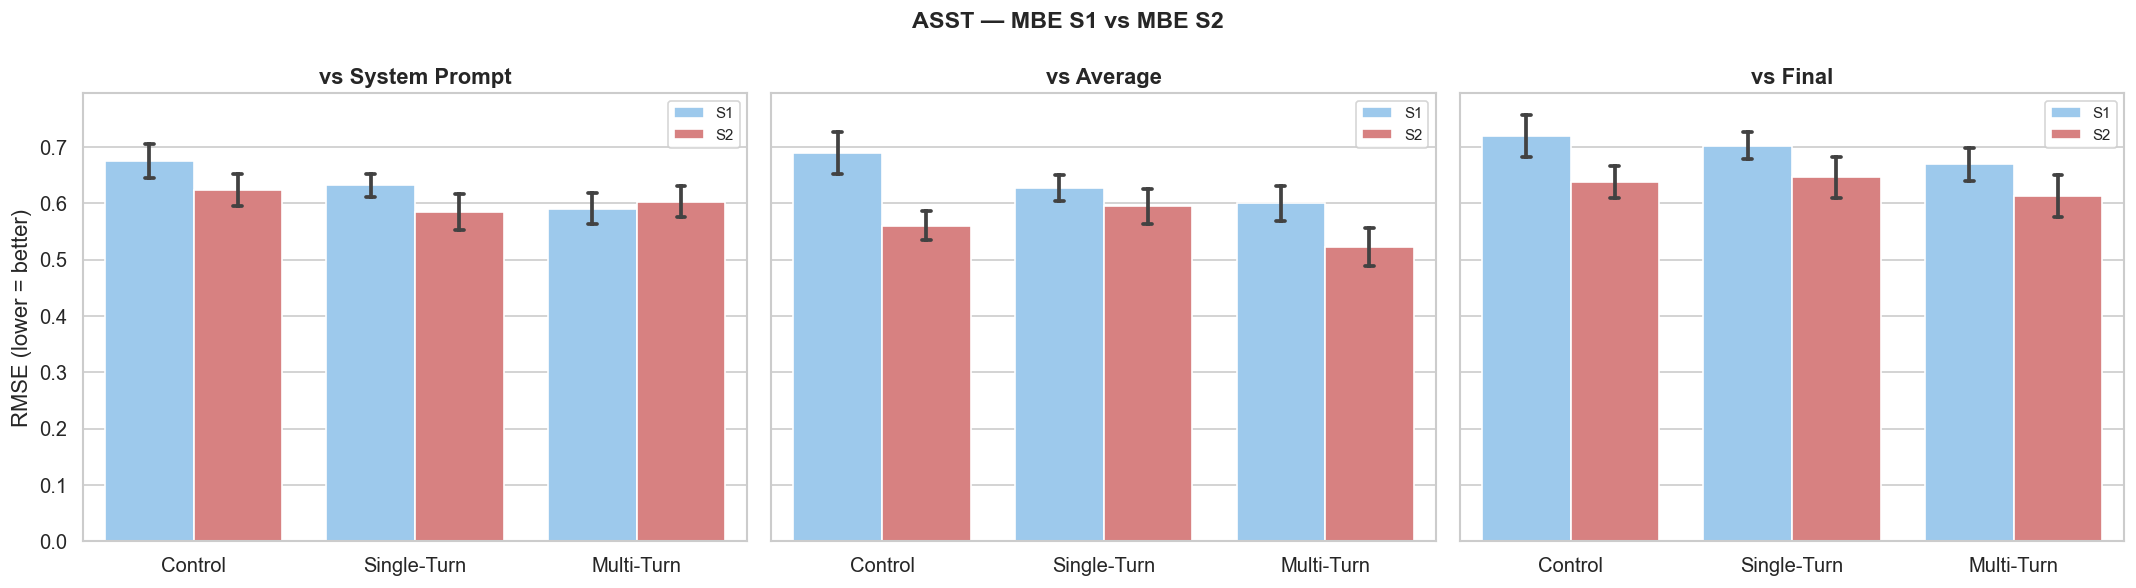

/var/folders/zz/78fqfyrj1lsdrh8ws2kmz9800000gn/T/ipykernel_6782/1405483160.py:120: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITION_ORDER])



ASST PROMPT (between-subjects, Mann-Whitney)

  --- MBA vs System Prompt ---
    Control     : S1=0.609 (n=40), S2=0.582 (n=41), p=0.6067 
    Single-Turn : S1=0.571 (n=45), S2=0.484 (n=40), p=0.0084 *
    Multi-Turn  : S1=0.543 (n=40), S2=0.532 (n=40), p=0.9348 

  --- MBE vs System Prompt ---
    Control     : S1=0.675 (n=40), S2=0.623 (n=41), p=0.2966 
    Single-Turn : S1=0.632 (n=45), S2=0.584 (n=40), p=0.5006 
    Multi-Turn  : S1=0.591 (n=40), S2=0.603 (n=40), p=0.5348 

  --- MBE vs Average ---
    Control     : S1=0.689 (n=40), S2=0.560 (n=41), p=0.0139 *
    Single-Turn : S1=0.627 (n=45), S2=0.594 (n=40), p=0.8087 
    Multi-Turn  : S1=0.600 (n=40), S2=0.522 (n=40), p=0.0913 

  --- MBE vs Final ---
    Control     : S1=0.719 (n=40), S2=0.638 (n=41), p=0.1393 
    Single-Turn : S1=0.702 (n=45), S2=0.646 (n=40), p=0.3575 
    Multi-Turn  : S1=0.669 (n=40), S2=0.613 (n=40), p=0.3531 


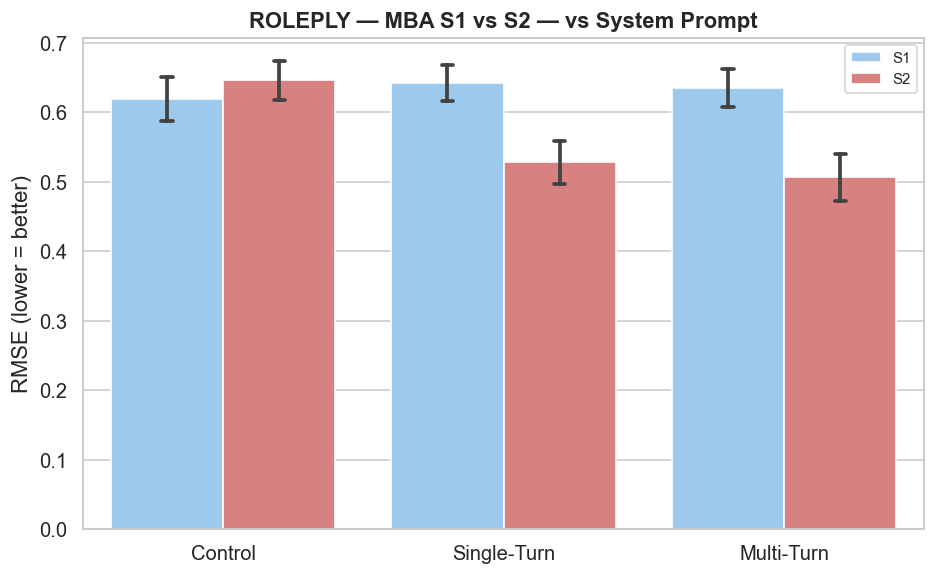

/var/folders/zz/78fqfyrj1lsdrh8ws2kmz9800000gn/T/ipykernel_6782/1405483160.py:138: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITION_ORDER])
/var/folders/zz/78fqfyrj1lsdrh8ws2kmz9800000gn/T/ipykernel_6782/1405483160.py:138: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITION_ORDER])
/var/folders/zz/78fqfyrj1lsdrh8ws2kmz9800000gn/T/ipykernel_6782/1405483160.py:138: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITION_ORDER])


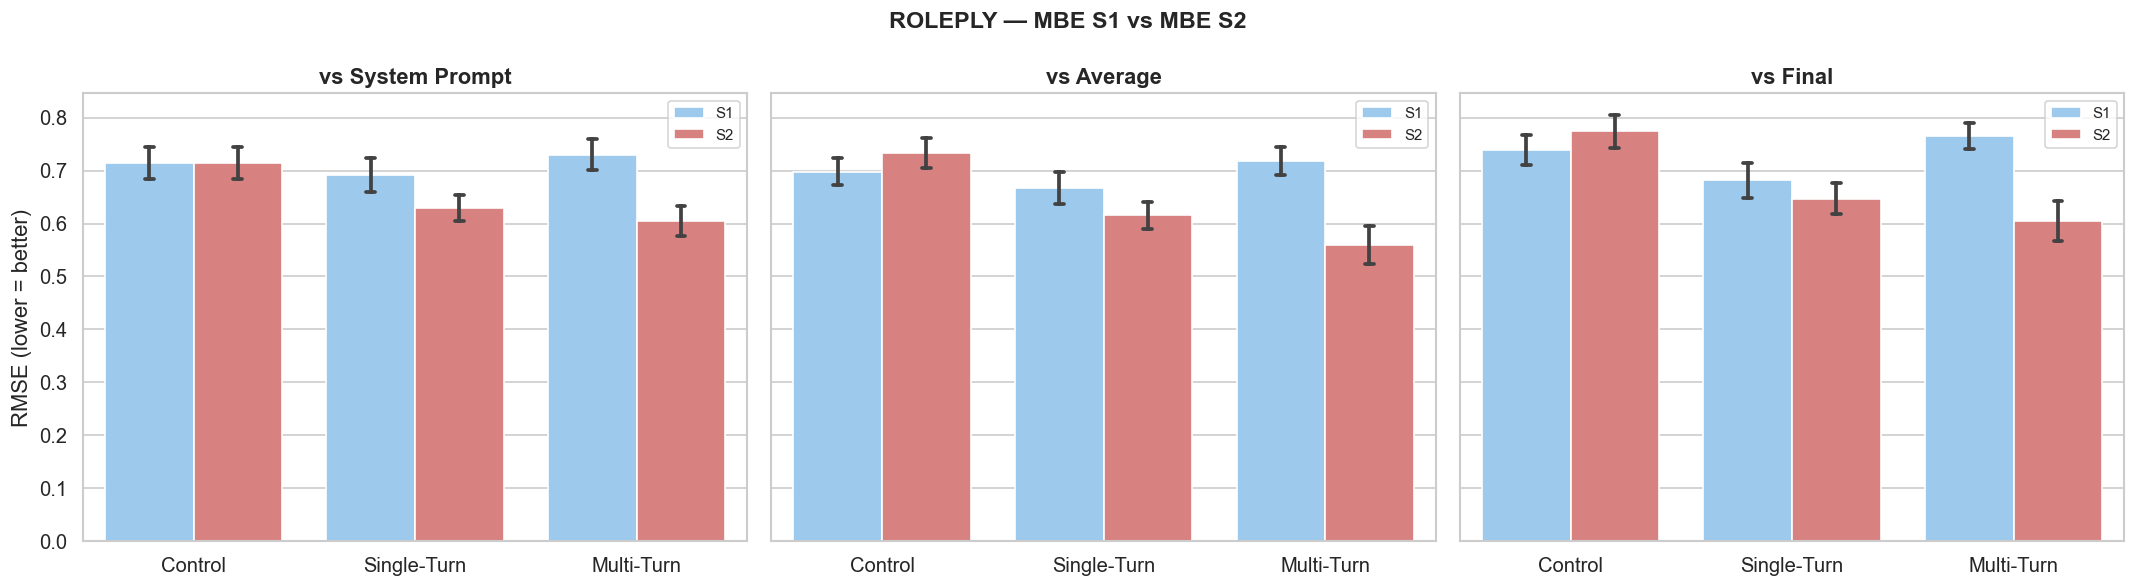


ROLEPLY PROMPT (between-subjects, Mann-Whitney)

  --- MBA vs System Prompt ---
    Control     : S1=0.619 (n=41), S2=0.646 (n=40), p=0.3771 
    Single-Turn : S1=0.642 (n=40), S2=0.527 (n=45), p=0.0086 *
    Multi-Turn  : S1=0.635 (n=40), S2=0.506 (n=40), p=0.0106 *

  --- MBE vs System Prompt ---
    Control     : S1=0.714 (n=41), S2=0.714 (n=40), p=0.9360 
    Single-Turn : S1=0.691 (n=40), S2=0.629 (n=45), p=0.0988 
    Multi-Turn  : S1=0.730 (n=40), S2=0.605 (n=40), p=0.0045 *

  --- MBE vs Average ---
    Control     : S1=0.698 (n=41), S2=0.733 (n=40), p=0.3424 
    Single-Turn : S1=0.668 (n=40), S2=0.616 (n=45), p=0.1140 
    Multi-Turn  : S1=0.718 (n=40), S2=0.559 (n=40), p=0.0015 *

  --- MBE vs Final ---
    Control     : S1=0.739 (n=41), S2=0.774 (n=40), p=0.4994 
    Single-Turn : S1=0.681 (n=40), S2=0.647 (n=45), p=0.2469 
    Multi-Turn  : S1=0.765 (n=40), S2=0.605 (n=40), p=0.0019 *


In [19]:
GT_LABELS = {'initial': 'System Prompt', 'avg': 'Average', 'final': 'Final'}

# ===== POOLED (within-subjects, Wilcoxon) =====

# --- MBA S1 vs MBA S2 (only vs system prompt) ---
fig, ax = plt.subplots(figsize=(8, 5))
df_wide['mba_initial_imp'] = df_wide['mba_initial_s1'] - df_wide['mba_initial_s2']
df_melt = df_wide.melt(id_vars=['firebase_id', 'condition_name'],
                        value_vars=['mba_initial_s1', 'mba_initial_s2'],
                        var_name='session', value_name='RMSE')
df_melt['session'] = df_melt['session'].map({'mba_initial_s1': 'S1', 'mba_initial_s2': 'S2'})
sns.barplot(data=df_melt, x='condition_name', y='RMSE', hue='session',
            order=CONDITION_ORDER, palette={'S1': '#90CAF9', 'S2': '#E57373'},
            ax=ax, errorbar='se', capsize=0.08)
ax.set_xlabel('')
ax.set_ylabel('RMSE (lower = better)')
ax.set_title('MBA S1 vs MBA S2 — vs System Prompt Activation', fontweight='bold')
ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITION_ORDER])
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('plots/calibration/mba_s1_vs_mba_s2.png', bbox_inches='tight')
plt.show()

# --- MBE S1 vs MBE S2 (vs all 3 ground truths) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle('MBE S1 vs MBE S2 — Post-chat evaluations', fontsize=14, fontweight='bold')
for ax, gt in zip(axes, ['initial', 'avg', 'final']):
    col_s1, col_s2 = f'mbe_{gt}_s1', f'mbe_{gt}_s2'
    df_melt = df_wide.melt(id_vars=['firebase_id', 'condition_name'],
                            value_vars=[col_s1, col_s2], var_name='session', value_name='RMSE')
    df_melt['session'] = df_melt['session'].map({col_s1: 'S1', col_s2: 'S2'})
    sns.barplot(data=df_melt, x='condition_name', y='RMSE', hue='session',
                order=CONDITION_ORDER, palette={'S1': '#90CAF9', 'S2': '#E57373'},
                ax=ax, errorbar='se', capsize=0.08)
    ax.set_xlabel('')
    ax.set_ylabel('RMSE (lower = better)' if ax == axes[0] else '')
    ax.set_title(f'vs {GT_LABELS[gt]} Activation', fontweight='bold')
    ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITION_ORDER])
    ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('plots/calibration/mbe_s1_vs_mbe_s2.png', bbox_inches='tight')
plt.show()

# --- Improvement bars ---
# MBA
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df_wide, x='condition_name', y='mba_initial_imp',
            order=CONDITION_ORDER, palette=CONDITION_COLORS, ax=ax, errorbar='se', capsize=0.1)
ax.axhline(y=0, color='black', linewidth=0.5, linestyle='--', alpha=0.3)
ax.set_xlabel('')
ax.set_ylabel('RMSE Improvement (S1 - S2)')
ax.set_title('MBA Improvement vs System Prompt\nPositive = S2 Better', fontweight='bold')
ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITION_ORDER])
plt.tight_layout()
plt.savefig('plots/calibration/mba_improvement.png', bbox_inches='tight')
plt.show()

# MBE
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle('MBE Improvement (S1→S2) — Positive = S2 Better', fontsize=14, fontweight='bold')
for ax, gt in zip(axes, ['initial', 'avg', 'final']):
    imp_col = f'mbe_{gt}_imp'
    df_wide[imp_col] = df_wide[f'mbe_{gt}_s1'] - df_wide[f'mbe_{gt}_s2']
    sns.barplot(data=df_wide, x='condition_name', y=imp_col,
                order=CONDITION_ORDER, palette=CONDITION_COLORS, ax=ax, errorbar='se', capsize=0.1)
    ax.axhline(y=0, color='black', linewidth=0.5, linestyle='--', alpha=0.3)
    ax.set_xlabel('')
    ax.set_ylabel('RMSE Improvement (S1 - S2)' if ax == axes[0] else '')
    ax.set_title(f'vs {GT_LABELS[gt]} Activation', fontweight='bold')
    ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITION_ORDER])
plt.tight_layout()
plt.savefig('plots/calibration/mbe_improvement.png', bbox_inches='tight')
plt.show()

# --- Pooled stats (within-subjects) ---
print(f'\n{"="*70}')
print(f'POOLED (within-subjects, Wilcoxon)')
print(f'{"="*70}')

print(f'\n  --- MBA vs System Prompt ---')
for cond in CONDITION_ORDER:
    imp = df_wide[df_wide['condition_name'] == cond]['mba_initial_imp'].dropna()
    try:
        w, p = sp_stats.wilcoxon(imp); sig = '*' if p < 0.05 else ''
    except: p, sig = np.nan, ''
    s1 = df_wide[df_wide['condition_name'] == cond]['mba_initial_s1'].mean()
    s2 = df_wide[df_wide['condition_name'] == cond]['mba_initial_s2'].mean()
    print(f'    {CONDITION_LABELS[cond]:12s}: S1={s1:.3f}, S2={s2:.3f}, imp={imp.mean():+.3f} (p={p:.4f}) {sig}')
groups = [df_wide[df_wide['condition_name'] == c]['mba_initial_imp'].dropna().values for c in CONDITION_ORDER]
h, p = sp_stats.kruskal(*[g for g in groups if len(g) > 0])
print(f'    Between-condition: H={h:.2f}, p={p:.4f} {"*" if p < 0.05 else ""}')

for gt in ['initial', 'avg', 'final']:
    imp_col = f'mbe_{gt}_imp'
    print(f'\n  --- MBE vs {GT_LABELS[gt]} ---')
    for cond in CONDITION_ORDER:
        imp = df_wide[df_wide['condition_name'] == cond][imp_col].dropna()
        try:
            w, p = sp_stats.wilcoxon(imp); sig = '*' if p < 0.05 else ''
        except: p, sig = np.nan, ''
        s1 = df_wide[df_wide['condition_name'] == cond][f'mbe_{gt}_s1'].mean()
        s2 = df_wide[df_wide['condition_name'] == cond][f'mbe_{gt}_s2'].mean()
        print(f'    {CONDITION_LABELS[cond]:12s}: S1={s1:.3f}, S2={s2:.3f}, imp={imp.mean():+.3f} (p={p:.4f}) {sig}')
    groups = [df_wide[df_wide['condition_name'] == c][imp_col].dropna().values for c in CONDITION_ORDER]
    h, p = sp_stats.kruskal(*[g for g in groups if len(g) > 0])
    print(f'    Between-condition: H={h:.2f}, p={p:.4f} {"*" if p < 0.05 else ""}')

# ===== PER PROMPT TYPE (between-subjects, Mann-Whitney) =====
for prompt_type in PROMPT_TYPES:
    df_pt = df_session_calib[df_session_calib['prompt_type'] == prompt_type]

    # MBA vs system prompt only
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(data=df_pt, x='condition_name', y='mba_initial_rmse', hue='session',
                order=CONDITION_ORDER, palette={1: '#90CAF9', 2: '#E57373'},
                ax=ax, errorbar='se', capsize=0.08)
    ax.set_xlabel('')
    ax.set_ylabel('RMSE (lower = better)')
    ax.set_title(f'{prompt_type} — MBA S1 vs S2 — vs System Prompt', fontweight='bold')
    ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITION_ORDER])
    handles, _ = ax.get_legend_handles_labels()
    ax.legend(handles, ['S1', 'S2'], fontsize=9)
    plt.tight_layout()
    plt.savefig(f'plots/calibration/mba_s1_vs_s2_{prompt_type.lower()}.png', bbox_inches='tight')
    plt.show()

    # MBE vs all 3 ground truths
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    fig.suptitle(f'{prompt_type} — MBE S1 vs MBE S2', fontsize=14, fontweight='bold')
    for ax, gt in zip(axes, ['initial', 'avg', 'final']):
        col = f'mbe_{gt}_rmse'
        sns.barplot(data=df_pt, x='condition_name', y=col, hue='session',
                    order=CONDITION_ORDER, palette={1: '#90CAF9', 2: '#E57373'},
                    ax=ax, errorbar='se', capsize=0.08)
        ax.set_xlabel('')
        ax.set_ylabel('RMSE (lower = better)' if ax == axes[0] else '')
        ax.set_title(f'vs {GT_LABELS[gt]}', fontweight='bold')
        ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITION_ORDER])
        handles, _ = ax.get_legend_handles_labels()
        ax.legend(handles, ['S1', 'S2'], fontsize=9)
    plt.tight_layout()
    plt.savefig(f'plots/calibration/mbe_s1_vs_s2_{prompt_type.lower()}.png', bbox_inches='tight')
    plt.show()

    # Stats
    print(f'\n{"="*70}')
    print(f'{prompt_type} PROMPT (between-subjects, Mann-Whitney)')
    print(f'{"="*70}')

    print(f'\n  --- MBA vs System Prompt ---')
    for cond in CONDITION_ORDER:
        cd = df_pt[df_pt['condition_name'] == cond]
        s1 = cd[cd['session'] == 1]['mba_initial_rmse'].dropna()
        s2 = cd[cd['session'] == 2]['mba_initial_rmse'].dropna()
        if len(s1) > 0 and len(s2) > 0:
            u, p = sp_stats.mannwhitneyu(s1, s2, alternative='two-sided'); sig = '*' if p < 0.05 else ''
        else: u, p, sig = np.nan, np.nan, ''
        print(f'    {CONDITION_LABELS[cond]:12s}: S1={s1.mean():.3f} (n={len(s1)}), S2={s2.mean():.3f} (n={len(s2)}), p={p:.4f} {sig}')

    for gt in ['initial', 'avg', 'final']:
        col = f'mbe_{gt}_rmse'
        print(f'\n  --- MBE vs {GT_LABELS[gt]} ---')
        for cond in CONDITION_ORDER:
            cd = df_pt[df_pt['condition_name'] == cond]
            s1 = cd[cd['session'] == 1][col].dropna()
            s2 = cd[cd['session'] == 2][col].dropna()
            if len(s1) > 0 and len(s2) > 0:
                u, p = sp_stats.mannwhitneyu(s1, s2, alternative='two-sided'); sig = '*' if p < 0.05 else ''
            else: u, p, sig = np.nan, np.nan, ''
            print(f'    {CONDITION_LABELS[cond]:12s}: S1={s1.mean():.3f} (n={len(s1)}), S2={s2.mean():.3f} (n={len(s2)}), p={p:.4f} {sig}')

## 8. Export JASP-Ready Calibration Data

One row per participant with S1/S2 RMSE, per-trait errors, and sign accuracy.

In [ ]:
TRAIT_NAMES = list(TRAIT_POLES.keys())

# Get initial and final activations
first_turns = df_pv[df_pv['turn'] == 0].set_index(['firebase_id', 'session'])
last_turns_idx = df_pv.sort_values('turn').groupby(['firebase_id', 'session']).last()
mean_activations = df_pv.groupby(['firebase_id', 'session'])[NET_TRAITS].mean()

jasp_rows = []
for _, p in df_parts.iterrows():
    fid = p['firebase_id']
    row = {
        'firebase_id': fid,
        'prolific_id': p['prolific_id'],
        'condition_name': p['condition_name'],
        'visualization_condition': p['visualization_condition'],
        'prompt_order': p['prompt_order'],
        's1_prompt_type': p['session1_prompt_type'],
        's2_prompt_type': p['session2_prompt_type'],
    }

    for sess in [1, 2]:
        prefix = f's{sess}'
        key = (fid, sess)

        # Get MBA and MBE ratings (normalized to [-1, 1])
        mba = {t: p.get(f'{prefix}_mba_{t}', np.nan) / 10.0 for t in TRAIT_NAMES}
        mbe = {t: p.get(f'{prefix}_mbe_{t}', np.nan) / 10.0 for t in TRAIT_NAMES}

        # Get actual activations
        if key in first_turns.index:
            initial = {t: first_turns.loc[key, f'net_{t}'] for t in TRAIT_NAMES}
        else:
            initial = {t: np.nan for t in TRAIT_NAMES}
        if key in last_turns_idx.index:
            final = {t: last_turns_idx.loc[key, f'net_{t}'] for t in TRAIT_NAMES}
        else:
            final = {t: np.nan for t in TRAIT_NAMES}
        if key in mean_activations.index:
            avg = {t: mean_activations.loc[key, f'net_{t}'] for t in TRAIT_NAMES}
        else:
            avg = {t: np.nan for t in TRAIT_NAMES}

        # RMSE across traits
        mba_init_errs = [mba[t] - initial[t] for t in TRAIT_NAMES]
        mbe_init_errs = [mbe[t] - initial[t] for t in TRAIT_NAMES]
        mbe_final_errs = [mbe[t] - final[t] for t in TRAIT_NAMES]
        mbe_avg_errs = [mbe[t] - avg[t] for t in TRAIT_NAMES]

        row[f'{prefix}_mba_initial_rmse'] = np.sqrt(np.nanmean(np.array(mba_init_errs)**2))
        row[f'{prefix}_mbe_initial_rmse'] = np.sqrt(np.nanmean(np.array(mbe_init_errs)**2))
        row[f'{prefix}_mbe_final_rmse'] = np.sqrt(np.nanmean(np.array(mbe_final_errs)**2))
        row[f'{prefix}_mbe_avg_rmse'] = np.sqrt(np.nanmean(np.array(mbe_avg_errs)**2))

        # Per-trait errors and sign accuracy
        sign_correct_count = 0
        sign_valid_count = 0
        for t in TRAIT_NAMES:
            mba_err = mba[t] - initial[t]
            mbe_final_err = mbe[t] - final[t]
            row[f'{prefix}_mba_initial_err_{t}'] = mba_err
            row[f'{prefix}_mbe_final_err_{t}'] = mbe_final_err
            row[f'{prefix}_mbe_final_abs_err_{t}'] = abs(mbe_final_err)

            # Sign correct: does MBE match the sign of the final activation?
            if np.isnan(mbe[t]) or np.isnan(final[t]) or mbe[t] == 0 or final[t] == 0:
                row[f'{prefix}_sign_correct_{t}'] = np.nan
            else:
                correct = np.sign(mbe[t]) == np.sign(final[t])
                row[f'{prefix}_sign_correct_{t}'] = float(correct)
                sign_valid_count += 1
                sign_correct_count += int(correct)

        row[f'{prefix}_sign_accuracy'] = (sign_correct_count / sign_valid_count
                                          if sign_valid_count > 0 else np.nan)

    jasp_rows.append(row)

df_jasp = pd.DataFrame(jasp_rows)
df_jasp.to_csv('data_calibration_jasp.csv', index=False)
print(f"Saved data_calibration_jasp.csv: {df_jasp.shape}")
print(f"Columns: {list(df_jasp.columns)}")